# 환경 설정

In [ ]:
# ---------------------------------------------------
# 구글 드라이브 연결
# Hello World !
# ---------------------------------------------------

import os

mount_point = '/content/drive'

if not os.path.ismount(mount_point): # 구글 드라이브가 마운트 되어 있는지 확인
    from google.colab import drive
    drive.mount(mount_point)
    print('\nGoogle Drive 마운트 완료')
    print('Hi there :)')
else:
    print('\nGoogle Drive가 이미 마운트되어 있습니다.')
    print('Still, hi!')


Mounted at /content/drive

Google Drive 마운트 완료
Hi there :)


In [ ]:
# ---------------------------------------------------
# ▶ 한글 설치
# ---------------------------------------------------
import importlib
import subprocess
# import os
# import matplotlib.pyplot as plt
# import matplotlib.font_manager as fm

def setup_korean_font():
    # matplotlib 설치 확인 및 설치
    # if importlib.util.find_spec("matplotlib") is None:
    #     subprocess.check_call(["pip", "install", "matplotlib"])
    #     import matplotlib.pyplot as plt
    #     import matplotlib.font_manager as fm

     # 설치 여부와 상관없이 항상 import 보장
    import matplotlib.pyplot as plt
    import matplotlib.font_manager as fm

    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

    # 나눔고딕 폰트가 없을 경우에만 설치
    if not os.path.exists(font_path):
        print("▶ step1: 나눔고딕 폰트를 설치합니다.")
        try:
            subprocess.check_call(["sudo", "apt-get", "install", "-y", "fonts-nanum"])
        except FileNotFoundError:
            subprocess.check_call(["apt-get", "install", "-y", "fonts-nanum"])
        subprocess.check_call(["fc-cache", "-fv"])
        subprocess.check_call(["rm", "-rf", os.path.expanduser("~/.cache/matplotlib")])

        # 폰트 등록 (중복 등록해도 문제 없음)
        fm.fontManager.addfont(font_path)
        plt.rcParams['font.family'] = 'NanumGothic'

        print("         폰트 설치 및 등록 완료!")

        # 음수 부호 깨짐 방지
        plt.rc('axes', unicode_minus=False)

        print("▶ step2: 한글 폰트에서 음수 부호 깨짐 방지 설정을 완료했습니다.")
    else:
        print("나눔고딕 폰트가 이미 설치되어 있습니다.")



# 실행
setup_korean_font()

▶ step1: 나눔고딕 폰트를 설치합니다.
         폰트 설치 및 등록 완료!
▶ step2: 한글 폰트에서 음수 부호 깨짐 방지 설정을 완료했습니다.


In [ ]:
# ---------------------------------------------------
# 2. 라이브러리 불러오기
# ---------------------------------------------------
section_length = 36  # 전체 길이

# 1) 기본 설정
section_name1 = ' basics '
print('\n' + section_name1.center(section_length, '-'))

import pandas as pd; print('Imported: pandas')
import numpy as np; print('Imported: numpy')
import math; print('Imported: math')


# 2) 시각화
section_name2 = ' visualization '
print('\n' + section_name2.center(section_length, '-'))

import matplotlib.pyplot as plt; print('Imported: matplotlib.pyplot')
import seaborn as sns; print('Imported: seaborn')


#3) 분석
section_name3 = ' analysis '
print('\n' + section_name3.center(section_length, '-'))

from sklearn.preprocessing import StandardScaler; print('Imported: StandardScaler')
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN; print('Imported: KMeans,')
print('          AgglomerativeClustering,')
print('          DBSCAN')
from sklearn.mixture import GaussianMixture; print('Imported: GaussianMixture')
from sklearn.decomposition import PCA; print('Imported: PCA')
from sklearn.metrics import silhouette_score; print('Imported: silhouette_score')

# from scipy.cluster.hierarchy import dendrogram, linkage; print('Imported: dendrogram,')
# print('          linkage')

# import warnings; print('Imported: warnings')
# warnings.filterwarnings('ignore')




-------------- basics --------------
Imported: pandas
Imported: numpy
Imported: math

---------- visualization -----------
Imported: matplotlib.pyplot
Imported: seaborn

------------- analysis -------------
Imported: StandardScaler
Imported: KMeans,
          AgglomerativeClustering,
          DBSCAN
Imported: GaussianMixture
Imported: PCA
Imported: silhouette_score


# 데이터 로드

In [ ]:
df_trial_register = pd.read_csv("/content/drive/MyDrive/중급프로젝트(4팀)/원본데이터/trial_register.csv")
df_trial_visit_info = pd.read_csv("/content/drive/MyDrive/중급프로젝트(4팀)/원본데이터/trial_visit_info.csv")
df_trial_access_log = pd.read_csv("/content/drive/MyDrive/중급프로젝트(4팀)/원본데이터/trial_access_log.csv")
df_trial_payment = pd.read_csv("/content/drive/MyDrive/중급프로젝트(4팀)/원본데이터/trial_payment.csv")
df_site_area = pd.read_csv("/content/drive/MyDrive/중급프로젝트(4팀)/원본데이터/site_area.csv")
df_merge = pd.read_csv("/content/drive/MyDrive/중급프로젝트(4팀)/수정데이터/df_merge_v3.csv")
df = pd.read_csv("/content/drive/MyDrive/중급프로젝트(4팀)/수정데이터/df_merge.csv")

## 결측값, 중복값, 분포 확인

1.   df_trial_register
*   결측값 X
*   중복행 O : (28행)


2.   df_trial_access_log
*   결측값 X
*   중복행 O : (359행)

3.   df_trial_visit_info
*   결측값 O : (555행)
*   중복행 O : (48행)

4.   df_site_area
*   결측값 X
*   중복행 X

5.   df_trial_payment
*   결측값 X
*   중복행 O : (35행)

### df_trial_register

In [ ]:
df_trial_register.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   trial_date  9659 non-null   object
 1   user_uuid   9659 non-null   object
dtypes: object(2)
memory usage: 151.1+ KB


In [ ]:
# 중복행이 총 몇인지 숫자로 빠르게 확인
df_trial_register.duplicated().sum()

np.int64(28)

In [ ]:
# 중복행 보기
data = df_trial_register[df_trial_register.duplicated(keep=False)]
data

,trial_date,user_uuid
17,2023-12-23,56231301-3408-4206-962d-aaa25a342821
18,2023-12-23,56231301-3408-4206-962d-aaa25a342821
21,2023-12-23,4c5b26a3-24d4-4b8f-a591-be80271c0aeb
22,2023-12-23,4c5b26a3-24d4-4b8f-a591-be80271c0aeb
27,2023-12-24,204ecb60-f9e3-42b4-ae7a-f1f00c939894
28,2023-12-24,204ecb60-f9e3-42b4-ae7a-f1f00c939894
29,2023-12-25,d9fc9841-6383-410e-9d76-2862f1b6e1af
30,2023-12-25,d9fc9841-6383-410e-9d76-2862f1b6e1af
99,2023-12-31,acf3e288-4487-492b-9477-df149fb72e83
100,2023-12-31,acf3e288-4487-492b-9477-df149fb72e83


In [ ]:
# 중복행 중 하나만 두고 나머지 삭제
df_trial_register = df_trial_register.drop_duplicates()
df_trial_register[df_trial_register.duplicated()]
# 중복행이 총 몇인지 숫자로 빠르게 확인
df_trial_register.duplicated().sum()

np.int64(0)

In [ ]:
df_trial_register.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9631 entries, 0 to 9658
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   trial_date  9631 non-null   object
 1   user_uuid   9631 non-null   object
dtypes: object(2)
memory usage: 225.7+ KB


In [ ]:
# df_trial_register에서 user_uuid별 최초 trial_date만 남김
df_trial_register = (
    df_trial_register
    .sort_values('trial_date')
    .drop_duplicates(subset='user_uuid', keep='first')
)


In [ ]:
df_trial_register['user_uuid'].nunique()

9624

### df_trial_access_log

In [ ]:
df_trial_access_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63708 entries, 0 to 63707
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         63708 non-null  int64 
 1   checkin    63708 non-null  int64 
 2   cdate      63708 non-null  object
 3   site_id    63708 non-null  int64 
 4   user_uuid  63708 non-null  object
dtypes: int64(3), object(2)
memory usage: 2.4+ MB


In [ ]:
# 중복행이 총 몇인지 숫자로 빠르게 확인
df_trial_access_log.duplicated().sum()
# 중복행 보기
data = df_trial_access_log[df_trial_access_log.duplicated(keep=False)]
data

,id,checkin,cdate,site_id,user_uuid
2216,2099278,2,2023-11-24 02:49:24.605801,1,906b191d-ccfe-45ab-9233-6445f631d1d1
2217,2099278,2,2023-11-24 02:49:24.605801,1,906b191d-ccfe-45ab-9233-6445f631d1d1
2218,2098815,1,2023-11-24 00:57:17.913935,1,906b191d-ccfe-45ab-9233-6445f631d1d1
2219,2098815,1,2023-11-24 00:57:17.913935,1,906b191d-ccfe-45ab-9233-6445f631d1d1
2220,2099031,2,2023-11-24 01:52:13.122963,1,906b191d-ccfe-45ab-9233-6445f631d1d1
...,...,...,...,...,...
63539,2155646,2,2023-12-16 09:18:38.006195,49,b981ed1d-7695-4a31-b0e8-347ec0011de9
63540,2155530,2,2023-12-16 08:20:52.737393,49,b981ed1d-7695-4a31-b0e8-347ec0011de9
63541,2155530,2,2023-12-16 08:20:52.737393,49,b981ed1d-7695-4a31-b0e8-347ec0011de9
63542,2155541,1,2023-12-16 08:24:28.344923,49,b981ed1d-7695-4a31-b0e8-347ec0011de9


In [ ]:
# 중복행 중 하나만 두고 나머지 삭제
df_trial_access_log = df_trial_access_log.drop_duplicates()
df_trial_access_log[df_trial_access_log.duplicated()]
# 중복행이 총 몇인지 숫자로 빠르게 확인
df_trial_access_log.duplicated().sum()

np.int64(0)

In [ ]:
df_trial_access_log.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63349 entries, 0 to 63707
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         63349 non-null  int64 
 1   checkin    63349 non-null  int64 
 2   cdate      63349 non-null  object
 3   site_id    63349 non-null  int64 
 4   user_uuid  63349 non-null  object
dtypes: int64(3), object(2)
memory usage: 2.9+ MB


In [ ]:
df_trial_access_log['user_uuid'].nunique()

6026

### df_trial_visit_info

In [ ]:
df_trial_visit_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11477 entries, 0 to 11476
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   site_id           11477 non-null  int64 
 1   date              11477 non-null  object
 2   stay_time         11477 non-null  object
 3   stay_time_second  11477 non-null  int64 
 4   first_enter_time  10922 non-null  object
 5   last_leave_time   10922 non-null  object
 6   user_uuid         11477 non-null  object
dtypes: int64(2), object(5)
memory usage: 627.8+ KB


In [ ]:
# 중복행이 총 몇인지 숫자로 빠르게 확인
df_trial_visit_info.duplicated().sum()
# 중복행 보기
data = df_trial_visit_info[df_trial_visit_info.duplicated(keep=False)]
data

,site_id,date,stay_time,stay_time_second,first_enter_time,last_leave_time,user_uuid
6,1,2023-12-23,05:27:51.797120,19671,2023-12-23 15:53:41.172357,2023-12-23 22:34:21.779882,4c5b26a3-24d4-4b8f-a591-be80271c0aeb
7,1,2023-12-23,05:27:51.797120,19671,2023-12-23 15:53:41.172357,2023-12-23 22:34:21.779882,4c5b26a3-24d4-4b8f-a591-be80271c0aeb
8,1,2023-12-24,07:58:18.169248,28698,2023-12-24 13:33:07.764120,2023-12-24 22:41:41.588923,4c5b26a3-24d4-4b8f-a591-be80271c0aeb
9,1,2023-12-24,07:58:18.169248,28698,2023-12-24 13:33:07.764120,2023-12-24 22:41:41.588923,4c5b26a3-24d4-4b8f-a591-be80271c0aeb
10,1,2023-12-25,02:17:57.796065,8277,2023-12-25 15:19:03.425532,2023-12-25 17:50:03.039029,4c5b26a3-24d4-4b8f-a591-be80271c0aeb
...,...,...,...,...,...,...,...
2478,49,2023-12-20,07:09:39.951308,25779,2023-12-20 09:04:51.790262,2023-12-20 17:51:06.131464,c6f9f925-b346-42ef-9fb8-b95e7c18824a
9611,6,2023-01-20,03:44:36.183743,13476,2023-01-20 09:40:38.266432,2023-01-20 13:25:14.450175,dceba5c8-20c2-497a-829a-74099f7ee5a8
9612,6,2023-01-20,03:44:36.183743,13476,2023-01-20 09:40:38.266432,2023-01-20 13:25:14.450175,dceba5c8-20c2-497a-829a-74099f7ee5a8
9613,6,2023-01-21,06:11:15.511499,22275,2023-01-21 12:54:12.025475,2023-01-21 23:24:30.217758,dceba5c8-20c2-497a-829a-74099f7ee5a8


In [ ]:
# 중복행 중 하나만 두고 나머지 삭제
df_trial_visit_info = df_trial_visit_info.drop_duplicates()
df_trial_visit_info[df_trial_visit_info.duplicated()]
# 중복행이 총 몇인지 숫자로 빠르게 확인
df_trial_visit_info.duplicated().sum()

np.int64(0)

In [ ]:
df_trial_visit_info['user_uuid'].nunique()

6534

### df_site_area

In [ ]:
df_site_area.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   site_id      9 non-null      int64
 1   area_pyeong  9 non-null      int64
dtypes: int64(2)
memory usage: 276.0 bytes


In [ ]:
# 중복행이 총 몇인지 숫자로 빠르게 확인
df_site_area.duplicated().sum()
# 중복행 보기
data = df_site_area[df_site_area.duplicated(keep=False)]
data

,site_id,area_pyeong


### df_trial_payment

In [ ]:
df_trial_payment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   is_payment  9659 non-null   int64 
 1   user_uuid   9659 non-null   object
dtypes: int64(1), object(1)
memory usage: 151.1+ KB


In [ ]:
# 중복행이 총 몇인지 숫자로 빠르게 확인
df_trial_payment.duplicated().sum()
# 중복행 보기
data = df_trial_payment[df_trial_payment.duplicated(keep=False)]
data

,is_payment,user_uuid
17,0,56231301-3408-4206-962d-aaa25a342821
18,0,56231301-3408-4206-962d-aaa25a342821
21,0,4c5b26a3-24d4-4b8f-a591-be80271c0aeb
22,0,4c5b26a3-24d4-4b8f-a591-be80271c0aeb
27,0,204ecb60-f9e3-42b4-ae7a-f1f00c939894
...,...,...
6903,0,969e4e79-950b-4608-90da-ac26aed52d55
6904,1,dceba5c8-20c2-497a-829a-74099f7ee5a8
6905,1,dceba5c8-20c2-497a-829a-74099f7ee5a8
6906,1,7c5f0d06-2b1a-4a47-8961-3f93813b4eb7


In [ ]:
# 중복행 중 하나만 두고 나머지 삭제
df_trial_payment = df_trial_payment.drop_duplicates()
df_trial_payment[df_trial_payment.duplicated()]
# 중복행이 총 몇인지 숫자로 빠르게 확인
df_trial_payment.duplicated().sum()

np.int64(0)

In [ ]:
df_trial_payment['user_uuid'].nunique()

9624

### 결측값 삭제

In [ ]:
df_trial_visit_info = df_trial_visit_info.dropna()

In [ ]:
df_trial_visit_info.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10874 entries, 0 to 11476
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   site_id           10874 non-null  int64 
 1   date              10874 non-null  object
 2   stay_time         10874 non-null  object
 3   stay_time_second  10874 non-null  int64 
 4   first_enter_time  10874 non-null  object
 5   last_leave_time   10874 non-null  object
 6   user_uuid         10874 non-null  object
dtypes: int64(2), object(5)
memory usage: 679.6+ KB


In [ ]:
df_trial_visit_info['user_uuid'].nunique()

6207

# 파생 변수 만들기

## df_trial_register
---
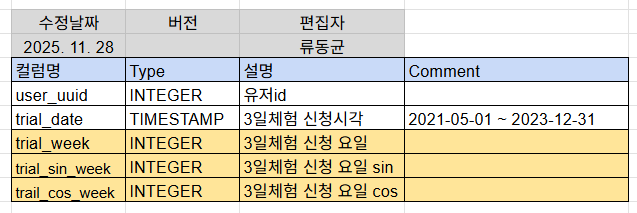

In [ ]:
df_trial_register

,trial_date,user_uuid
427,2021-05-01,badbde4d-886b-4992-a8e3-fd0c05640183
425,2021-05-01,e079e682-62f2-4c05-84b9-86913e3dc146
428,2021-05-01,f25078d1-1030-485c-85c5-dc82d6987043
429,2021-05-01,844319ff-cd15-4633-9900-6eaf4dc68b68
431,2021-05-01,9f5e2bd3-65c9-4800-84c1-f5c93f44d096
...,...,...
90,2023-12-30,e9b1a5df-d70c-4ccf-af22-64fdae98d3a2
95,2023-12-30,aa4773c8-dbc9-4c80-849b-1ab8d1db7bda
99,2023-12-31,acf3e288-4487-492b-9477-df149fb72e83
101,2023-12-31,0e58ea5a-ebe4-48cb-b31b-d02a4f350cf8


### trail_week, sin, cos

In [ ]:
# trial_date가 datetime이 아니라면 변환
df_trial_register['trial_date'] = pd.to_datetime(df_trial_register['trial_date'])

# 1) trial_week (요일)
# 월=0, 화=1, … 일=6
df_trial_register['trial_week'] = df_trial_register['trial_date'].dt.weekday

# 2) trial_sin_week (요일 sin)
df_trial_register['trial_sin_week'] = np.sin(2 * np.pi * df_trial_register['trial_week'] / 7)

# 3) trial_cos_week (요일 cos)
df_trial_register['trial_cos_week'] = np.cos(2 * np.pi * df_trial_register['trial_week'] / 7)

In [ ]:
df_trial_register

,trial_date,user_uuid,trial_week,trial_sin_week,trial_cos_week
427,2021-05-01,badbde4d-886b-4992-a8e3-fd0c05640183,5,-0.974928,-0.222521
425,2021-05-01,e079e682-62f2-4c05-84b9-86913e3dc146,5,-0.974928,-0.222521
428,2021-05-01,f25078d1-1030-485c-85c5-dc82d6987043,5,-0.974928,-0.222521
429,2021-05-01,844319ff-cd15-4633-9900-6eaf4dc68b68,5,-0.974928,-0.222521
431,2021-05-01,9f5e2bd3-65c9-4800-84c1-f5c93f44d096,5,-0.974928,-0.222521
...,...,...,...,...,...
90,2023-12-30,e9b1a5df-d70c-4ccf-af22-64fdae98d3a2,5,-0.974928,-0.222521
95,2023-12-30,aa4773c8-dbc9-4c80-849b-1ab8d1db7bda,5,-0.974928,-0.222521
99,2023-12-31,acf3e288-4487-492b-9477-df149fb72e83,6,-0.781831,0.623490
101,2023-12-31,0e58ea5a-ebe4-48cb-b31b-d02a4f350cf8,6,-0.781831,0.623490


## df_trial_access_log
---
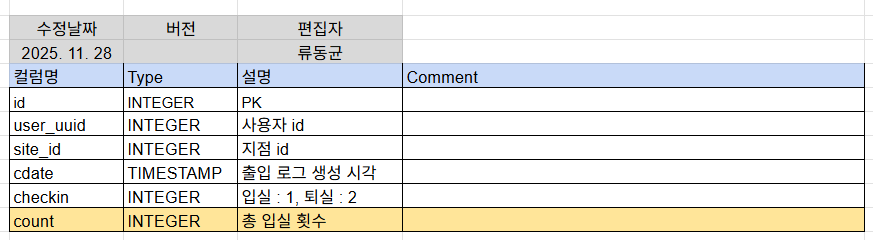

In [ ]:
df_trial_access_log

,id,checkin,cdate,site_id,user_uuid
0,1719038,1,2023-07-07 07:11:55.201673,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
1,1716702,2,2023-07-06 15:15:58.761284,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
2,1719956,2,2023-07-07 14:10:41.848998,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
3,1716588,1,2023-07-06 13:09:48.758097,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
4,1719649,1,2023-07-07 10:12:42.083352,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
...,...,...,...,...,...
63703,1525518,2,2023-04-26 09:04:44.770319,49,8b271f57-2ce2-4b32-80b8-0fabb98390a7
63704,1524555,1,2023-04-26 06:09:14.228682,49,8b271f57-2ce2-4b32-80b8-0fabb98390a7
63705,2043662,1,2023-11-04 11:50:10.657353,49,c02b96c8-bcba-4f8c-baf8-99f6c35076f4
63706,2043791,2,2023-11-04 13:31:41.599473,49,c02b96c8-bcba-4f8c-baf8-99f6c35076f4


### day1_count/day2_count/day3_count

In [ ]:
import pytz
df = df_trial_access_log.copy()

df['cdate'] = pd.to_datetime(df['cdate'], utc=True)   # UTC 로 인식된 경우
KST = pytz.timezone('Asia/Seoul')

# 1) KST로 변환
df['cdate_kst'] = df['cdate'].dt.tz_convert(KST)

# 2) 날짜(date) 추출 (KST 기준)
df['date_kst'] = df['cdate_kst'].dt.date

# 3) 입실 로그만 사용
df_in = df[df['checkin'] == 1].copy()

# 4) 사용자별 방문 날짜 순서 부여
df_in['date_rank'] = df_in.groupby('user_uuid')['date_kst'] \
                          .rank(method='dense') \
                          .astype(int)

# 5) 각 날짜별 방문 횟수 계산
day_count = df_in.groupby(['user_uuid', 'date_rank']).size() \
                 .reset_index(name='cnt')

# 6) wide 변환 → day1/day2/day3 count
day_count_wide = day_count.pivot(index='user_uuid',
                                 columns='date_rank',
                                 values='cnt').reset_index()

# 컬럼명 정리
day_count_wide = day_count_wide.rename(columns={
    1: 'day1_count',
    2: 'day2_count',
    3: 'day3_count'
})

# 없는 컬럼 0으로 추가
for col in ['day1_count', 'day2_count', 'day3_count']:
    if col not in day_count_wide.columns:
        day_count_wide[col] = 0

day_count_wide = day_count_wide.fillna(0)

# 7) 원본 df에 merge
df_trial_access_log = df_trial_access_log.merge(
    day_count_wide,
    on='user_uuid',
    how='left'
)

# 8) 결측치 0으로
df_trial_access_log[['day1_count','day2_count','day3_count']] = \
    df_trial_access_log[['day1_count','day2_count','day3_count']].fillna(0).astype(int)

In [ ]:
# 0) cdate를 datetime으로 변환
df_trial_access_log['cdate'] = pd.to_datetime(df_trial_access_log['cdate'], utc=True)   # UTC 로 인식된 경우
KST = pytz.timezone('Asia/Seoul')
df_trial_access_log['cdate'] = df_trial_access_log['cdate'].dt.tz_convert(KST)
df_trial_access_log[df_trial_access_log['user_uuid'] == 'cacd0adb-2c87-450f-8a00-2b2ea6b8fa89'].sort_values('cdate')



,id,checkin,cdate,site_id,user_uuid,day1_count,day2_count,day3_count
3,1716588,1,2023-07-06 22:09:48.758097+09:00,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89,1,5,0
1,1716702,2,2023-07-07 00:15:58.761284+09:00,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89,1,5,0
5,1716712,1,2023-07-07 00:28:39.279318+09:00,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89,1,5,0
6,1716731,2,2023-07-07 03:17:33.011298+09:00,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89,1,5,0
0,1719038,1,2023-07-07 16:11:55.201673+09:00,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89,1,5,0
8,1719535,2,2023-07-07 18:22:36.745763+09:00,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89,1,5,0
4,1719649,1,2023-07-07 19:12:42.083352+09:00,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89,1,5,0
9,1719752,2,2023-07-07 20:09:52.861538+09:00,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89,1,5,0
7,1719953,1,2023-07-07 23:08:25.192590+09:00,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89,1,5,0
2,1719956,2,2023-07-07 23:10:41.848998+09:00,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89,1,5,0


## df_trial_visit_info
---
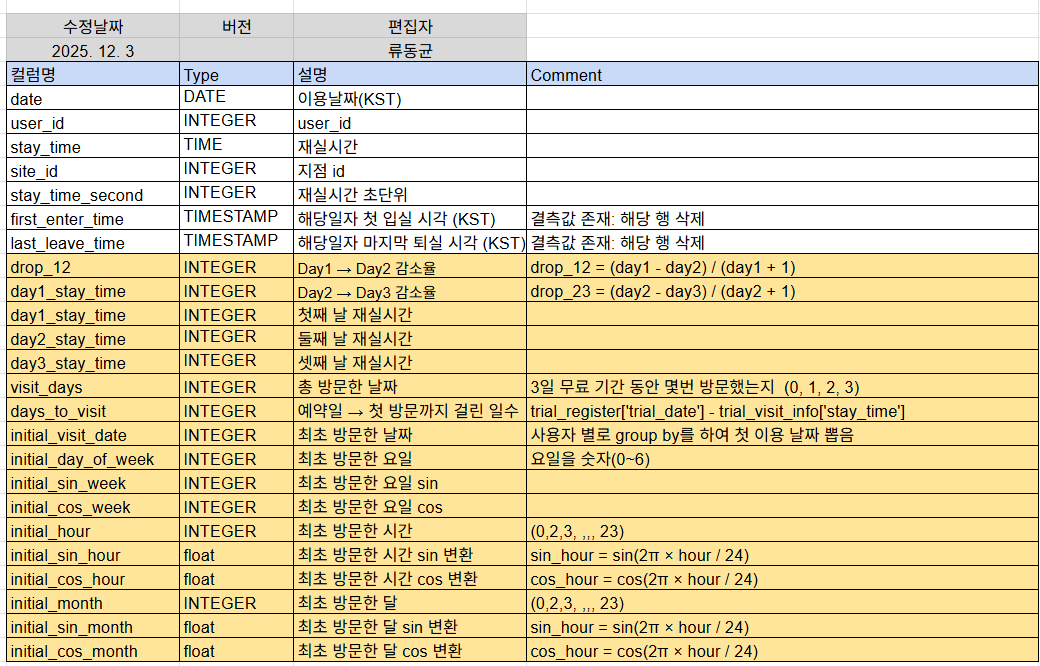

In [ ]:
df_trial_visit_info['user_uuid'].nunique()

6207

In [ ]:
import pandas as pd
import numpy as np

# ============================================
# 0) 데이터 복사
# ============================================
df = df_trial_visit_info.copy()

# ============================================
# 1) datetime 변환
# ============================================
df['date'] = pd.to_datetime(df['date'], format='mixed')
df['first_enter_time'] = pd.to_datetime(df['first_enter_time'], format='mixed')
df['last_leave_time'] = pd.to_datetime(df['last_leave_time'], format='mixed')

# ============================================
# 2) 날짜 순위 (day1 / day2 / day3)
# ============================================
df = df.sort_values(['user_uuid', 'date'])
df['date_rank'] = df.groupby('user_uuid')['date'].rank(method='dense').astype(int)
df = df[df['date_rank'].isin([1,2,3])]

# ============================================
# 3) day1/2/3 체류시간 pivot
# ============================================
day_pivot = df.pivot_table(
    index='user_uuid',
    columns='date_rank',
    values='stay_time_second',
    aggfunc='sum'
).reset_index()

day_pivot = day_pivot.rename(columns={
    1: 'day1_stay_time',
    2: 'day2_stay_time',
    3: 'day3_stay_time'
})

for c in ['day1_stay_time','day2_stay_time','day3_stay_time']:
    if c not in day_pivot.columns:
        day_pivot[c] = 0

day_pivot = day_pivot.fillna(0)

# 감소율
day_pivot['drop_12'] = (day_pivot['day1_stay_time'] - day_pivot['day2_stay_time']) / (day_pivot['day1_stay_time'] + 1)
day_pivot['drop_23'] = (day_pivot['day2_stay_time'] - day_pivot['day3_stay_time']) / (day_pivot['day2_stay_time'] + 1)

# ============================================
# 4) 방문일수
# ============================================
visit_days = df.groupby('user_uuid')['date_rank'].nunique().reset_index()
visit_days = visit_days.rename(columns={'date_rank':'visit_days'})

# ============================================
# 5) day1 최초 방문정보
# ============================================
first = df[df['date_rank']==1].sort_values(['user_uuid','date']).groupby('user_uuid').first().reset_index()

first['initial_visit_date'] = first['date']
first['initial_date'] = first['date']
first['initial_dow'] = first['date'].dt.dayofweek

first['initial_sin_week'] = np.sin(2*np.pi*first['initial_dow']/7)
first['initial_cos_week'] = np.cos(2*np.pi*first['initial_dow']/7)

first['initial_hour'] = first['first_enter_time'].dt.hour
first['initial_sin_hour'] = np.sin(2*np.pi*first['initial_hour']/24)
first['initial_cos_hour'] = np.cos(2*np.pi*first['initial_hour']/24)

first['initial_month'] = first['date'].dt.month
first['initial_sin_month'] = np.sin(2*np.pi*first['initial_month']/12)
first['initial_cos_month'] = np.cos(2*np.pi*first['initial_month']/12)

first = first[['user_uuid',
               'initial_visit_date','initial_date','initial_dow',
               'initial_sin_week','initial_cos_week',
               'initial_hour','initial_sin_hour','initial_cos_hour',
               'initial_month','initial_sin_month','initial_cos_month']]

# ============================================
# 6) day2/day3 최초 방문 날짜·요일·시간 sin/cos 추출 함수
# ============================================
def extract_day_first(df, rank):
    tmp = df[df['date_rank']==rank].sort_values(['user_uuid','first_enter_time'])
    tmp = tmp.groupby('user_uuid').first().reset_index()

    tmp[f'day{rank}_date'] = tmp['date']
    tmp[f'day{rank}_dow'] = tmp['date'].dt.dayofweek
    tmp[f'day{rank}_hour'] = tmp['first_enter_time'].dt.hour
    tmp[f'day{rank}_sin_hour'] = np.sin(2*np.pi * tmp[f'day{rank}_hour'] / 24)
    tmp[f'day{rank}_cos_hour'] = np.cos(2*np.pi * tmp[f'day{rank}_hour'] / 24)

    return tmp[['user_uuid',
                f'day{rank}_date', f'day{rank}_dow',
                f'day{rank}_hour', f'day{rank}_sin_hour', f'day{rank}_cos_hour']]

day2 = extract_day_first(df, 2)
day3 = extract_day_first(df, 3)

# ============================================
# 7) day별 site_id 추출
# ============================================
def extract_day_site(df, rank):
    tmp = df[df['date_rank']==rank].sort_values(['user_uuid','date'])
    tmp = tmp.groupby('user_uuid').first().reset_index()
    tmp = tmp[['user_uuid','site_id']].rename(columns={'site_id':f'day{rank}_site_id'})
    return tmp

day1_site = extract_day_site(df, 1)
day2_site = extract_day_site(df, 2)
day3_site = extract_day_site(df, 3)

# ============================================
# 8) trial_date
# ============================================
trial = df_trial_register[['user_uuid','trial_date']].copy()
trial['trial_date'] = pd.to_datetime(trial['trial_date'], format='mixed')

# ============================================
# 9) merge → df_final 생성
# ============================================
df_final = (day_pivot
    .merge(visit_days, on='user_uuid', how='left')
    .merge(first, on='user_uuid', how='left')
    .merge(day2, on='user_uuid', how='left')
    .merge(day3, on='user_uuid', how='left')
    .merge(day1_site, on='user_uuid', how='left')
    .merge(day2_site, on='user_uuid', how='left')
    .merge(day3_site, on='user_uuid', how='left')
    .merge(trial, on='user_uuid', how='left')
)

df_final['days_to_visit'] = (df_final['initial_visit_date'] - df_final['trial_date']).dt.days
df_final = df_final.drop(columns=['trial_date'])
df_final = df_final.fillna(0)


In [ ]:
df_final

,user_uuid,day1_stay_time,day2_stay_time,day3_stay_time,drop_12,drop_23,visit_days,initial_visit_date,initial_date,initial_dow,...,day2_cos_hour,day3_date,day3_dow,day3_hour,day3_sin_hour,day3_cos_hour,day1_site_id,day2_site_id,day3_site_id,days_to_visit
0,000590dc-046f-462b-8225-4c81a97b7166,21417.0,0.0,0.0,0.999953,0.000000,1,2023-09-05,2023-09-05,1,...,0.000000,0,0.0,0.0,0.000000,0.000000,6,0.0,0.0,1
1,000be14f-ba0f-4af6-bc2c-7b00dfcbc98c,10222.0,9382.0,25965.0,0.082168,-1.767345,3,2021-09-30,2021-09-30,3,...,0.258819,2021-10-02 00:00:00,5.0,13.0,-0.258819,-0.965926,3,3.0,3.0,1
2,0018e22d-a2cc-4e06-bca2-d6a041770f3b,42900.0,34472.0,0.0,0.196452,0.999971,2,2023-11-15,2023-11-15,2,...,-0.707107,0,0.0,0.0,0.000000,0.000000,6,6.0,0.0,1
3,002606d9-38ca-48f3-910c-cbfada9a9109,12689.0,12335.0,0.0,0.027896,0.999919,2,2023-01-07,2023-01-07,5,...,-0.707107,0,0.0,0.0,0.000000,0.000000,17,17.0,0.0,1
4,002a7570-90dd-4cab-b0aa-b0e40f7ef27a,18722.0,4887.0,0.0,0.738931,0.999795,2,2021-09-08,2021-09-08,2,...,-0.258819,0,0.0,0.0,0.000000,0.000000,5,5.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6202,ffc40f65-7634-4272-b73b-55d40be035ff,22808.0,17578.0,16772.0,0.229295,0.045850,3,2022-10-20,2022-10-20,3,...,-0.866025,2022-10-22 00:00:00,5.0,14.0,-0.500000,-0.866025,6,6.0,6.0,1
6203,ffcb7950-d150-40ae-a6bf-f85f5c2b9702,15154.0,14459.0,0.0,0.045859,0.999931,2,2022-04-26,2022-04-26,1,...,-0.866025,0,0.0,0.0,0.000000,0.000000,2,2.0,0.0,1
6204,ffce32ca-2efc-4485-b685-4b65811c2dcf,8450.0,0.0,0.0,0.999882,0.000000,1,2023-11-02,2023-11-02,3,...,0.000000,0,0.0,0.0,0.000000,0.000000,4,0.0,0.0,1
6205,ffd287bc-2797-4788-82fa-6268c82e7fa9,9672.0,23702.0,19481.0,-1.450429,0.178079,3,2023-04-07,2023-04-07,4,...,-0.707107,2023-04-09 00:00:00,6.0,15.0,-0.707107,-0.707107,6,6.0,6.0,1


In [ ]:
df_final.columns.tolist()

['user_uuid',
 'day1_stay_time',
 'day2_stay_time',
 'day3_stay_time',
 'drop_12',
 'drop_23',
 'visit_days',
 'initial_visit_date',
 'initial_date',
 'initial_dow',
 'initial_sin_week',
 'initial_cos_week',
 'initial_hour',
 'initial_sin_hour',
 'initial_cos_hour',
 'initial_month',
 'initial_sin_month',
 'initial_cos_month',
 'day2_date',
 'day2_dow',
 'day2_hour',
 'day2_sin_hour',
 'day2_cos_hour',
 'day3_date',
 'day3_dow',
 'day3_hour',
 'day3_sin_hour',
 'day3_cos_hour',
 'day1_site_id',
 'day2_site_id',
 'day3_site_id',
 'days_to_visit']

# 데이터 합치기


In [ ]:
df1 = df_trial_register[['user_uuid','trial_sin_week','trial_cos_week']]

In [ ]:
df2 = df_final #trial_visit_info

In [ ]:
df3 = df_trial_payment

In [ ]:
print("df1 고유 user_uuid:", df1['user_uuid'].nunique())
print("df2 고유 user_uuid:", df2['user_uuid'].nunique())
print("df3 고유 user_uuid:", df3['user_uuid'].nunique())


df1 고유 user_uuid: 9624
df2 고유 user_uuid: 6207
df3 고유 user_uuid: 9624


In [ ]:
# df1: trial_register
# df2: trial_visit_info  (df_final)
# df3: trial_payment

# 1. register + trial_visit_info
df_merge = df2.merge(df1, on='user_uuid', how='left')


# 2. + payment (결제 여부만 있으면 필요한 컬럼만 가져오기)
df_merge = df_merge.merge(df3[['user_uuid', 'is_payment']],
                          on='user_uuid',
                          how='left')

df_merge.head()


,user_uuid,day1_stay_time,day2_stay_time,day3_stay_time,drop_12,drop_23,visit_days,initial_visit_date,initial_date,initial_dow,...,day3_hour,day3_sin_hour,day3_cos_hour,day1_site_id,day2_site_id,day3_site_id,days_to_visit,trial_sin_week,trial_cos_week,is_payment
0,000590dc-046f-462b-8225-4c81a97b7166,21417.0,0.0,0.0,0.999953,0.000000,1,2023-09-05,2023-09-05,1,...,0.0,0.000000,0.000000,6,0.0,0.0,1,0.000000,1.000000,0
1,000be14f-ba0f-4af6-bc2c-7b00dfcbc98c,10222.0,9382.0,25965.0,0.082168,-1.767345,3,2021-09-30,2021-09-30,3,...,13.0,-0.258819,-0.965926,3,3.0,3.0,1,0.974928,-0.222521,1
2,0018e22d-a2cc-4e06-bca2-d6a041770f3b,42900.0,34472.0,0.0,0.196452,0.999971,2,2023-11-15,2023-11-15,2,...,0.0,0.000000,0.000000,6,6.0,0.0,1,0.781831,0.623490,0
3,002606d9-38ca-48f3-910c-cbfada9a9109,12689.0,12335.0,0.0,0.027896,0.999919,2,2023-01-07,2023-01-07,5,...,0.0,0.000000,0.000000,17,17.0,0.0,1,-0.433884,-0.900969,0
4,002a7570-90dd-4cab-b0aa-b0e40f7ef27a,18722.0,4887.0,0.0,0.738931,0.999795,2,2021-09-08,2021-09-08,2,...,0.0,0.000000,0.000000,5,5.0,0.0,1,0.781831,0.623490,1


In [ ]:
df_merge = df_merge.drop_duplicates(subset='user_uuid', keep='first')


In [ ]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6207 entries, 0 to 6206
Data columns (total 35 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   user_uuid           6207 non-null   object        
 1   day1_stay_time      6207 non-null   float64       
 2   day2_stay_time      6207 non-null   float64       
 3   day3_stay_time      6207 non-null   float64       
 4   drop_12             6207 non-null   float64       
 5   drop_23             6207 non-null   float64       
 6   visit_days          6207 non-null   int64         
 7   initial_visit_date  6207 non-null   datetime64[ns]
 8   initial_date        6207 non-null   datetime64[ns]
 9   initial_dow         6207 non-null   int32         
 10  initial_sin_week    6207 non-null   float64       
 11  initial_cos_week    6207 non-null   float64       
 12  initial_hour        6207 non-null   int32         
 13  initial_sin_hour    6207 non-null   float64     

In [ ]:
df_merge.to_csv('/content/drive/MyDrive/중급프로젝트(4팀)/수정데이터/df_merge_v3.csv', index=False, encoding='utf-8-sig')

# 변수 탐색 및 기본 EDA

## 전환율
---
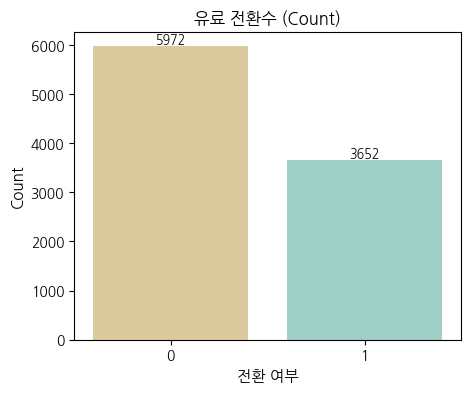
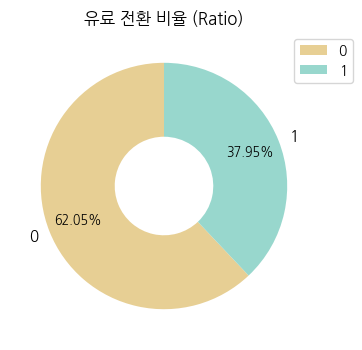

In [ ]:
# is_payment 변수의 '1'(결제)/'0'(미결제)) 확인
target_counts = df_trial_payment['is_payment'].value_counts()
target_ratio = df_trial_payment['is_payment'].value_counts(normalize=True) * 100

print("유료전환여부 여부")
print(f"no: {target_counts[0]:,}명 ({target_ratio[0]:.1f}%)")
print(f"yes: {target_counts[1]:,}명 ({target_ratio[1]:.1f}%)")
print(f"\n불균형 비율: {target_ratio[0]/target_ratio[1]:.1f}:1")

In [ ]:
#is_payment 변수 분포 시각화

colors = sns.color_palette('BrBG', n_colors=2)

plt.figure(figsize=(5, 4))
sns.countplot(x="is_payment", data=df_trial_payment, palette=colors)
plt.title(f"유료 전환수 (Count)", fontsize=12)
plt.xlabel("전환 여부", fontsize=11)
plt.ylabel("Count", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

for c in plt.gca().containers:
  plt.bar_label(c, fontsize=9)

plt.show()


# 도넛차트
plt.figure(figsize=(5, 4))

wedges, texts, autotexts = plt.pie(
    target_counts,
    labels=target_counts.index,
    autopct='%1.2f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.75,       # 퍼센트 글자 위치 (0~1, 커질수록 밖으로)
    labeldistance=1.1,      # 라벨 위치 (1 초과면 바깥)
    wedgeprops={'width': 0.6}   # 도넛 두께
)

for text in texts:
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_color("black")

plt.title("유료 전환 비율 (Ratio)")
plt.legend(bbox_to_anchor=(0.9,1))
plt.show()

plt.tight_layout()
plt.show()

## 일수별 데이터 분석
---
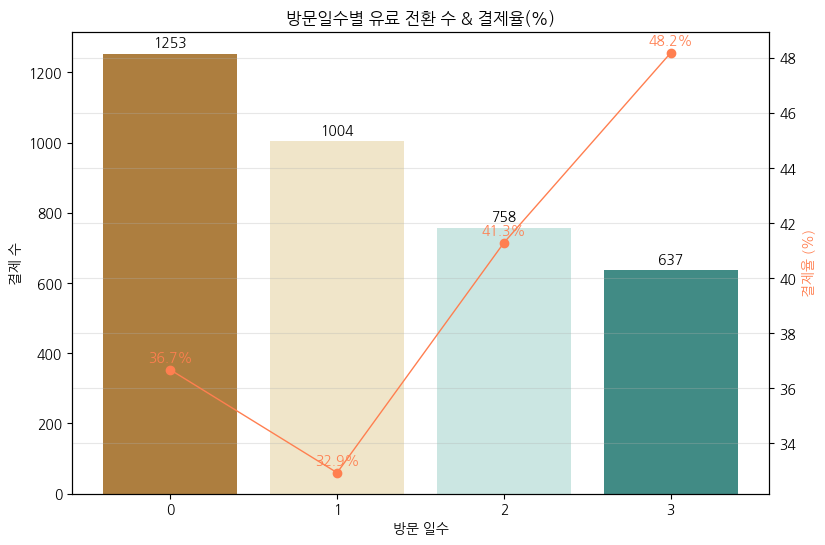
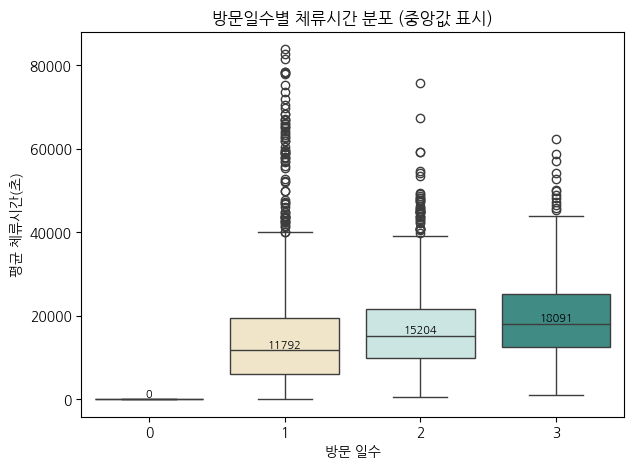

In [ ]:
# visit 날짜 변환
df_trial_visit_info['visit_dt'] = pd.to_datetime(df_trial_visit_info['date'], errors='coerce')

# user별 방문일수(고유 날짜 수)
visit_days = (
    df_trial_visit_info.groupby('user_uuid')['visit_dt']
         .nunique()
         .reset_index()
         .rename(columns={'visit_dt':'visit_days'})
)

# 4일 방문 → 3일 방문으로 통일
visit_days.loc[visit_days['visit_days'] >= 4, 'visit_days'] = 3


In [ ]:
# 등록일 변환
df_trial_register['reg_dt'] = pd.to_datetime(df_trial_register['trial_date'], errors='coerce')

# 최초 방문일
first_visit = (
    df_trial_visit_info.groupby('user_uuid')['visit_dt']
         .min()
         .reset_index()
         .rename(columns={'visit_dt':'first_visit_dt'})
)

In [ ]:
reg_visit = df_trial_register.merge(first_visit, on='user_uuid', how='left')

reg_visit['reserve_to_visit_days'] = (
    reg_visit['first_visit_dt'] - reg_visit['reg_dt']
).dt.days

# delay 구간화
reg_visit['delay_bin'] = pd.cut(
    reg_visit['reserve_to_visit_days'],
    bins=[-1, 0, 1, 2, 5, 10, 30, 999],
    labels=['0일', '1일', '2일', '3~5일', '6~10일', '11~30일', '30일+']
)


In [ ]:
# 결제 정보 merge
df_user = (
    df_trial_register[['user_uuid', 'reg_dt']]
    .merge(first_visit, on='user_uuid', how='left')
    .merge(visit_days, on='user_uuid', how='left')
    .merge(df_trial_payment[['user_uuid', 'is_payment']], on='user_uuid', how='left')
    .merge(reg_visit[['user_uuid', 'delay_bin']], on='user_uuid', how='left')
)

df_user['is_payment'] = df_user['is_payment'].fillna(0).astype(int)
df_user['visit_days'] = df_user['visit_days'].fillna(0).astype(int)


In [ ]:
# df_user visit_days 보장(이미 만들었음)
df_user['visit_days'] = df_user['visit_days'].fillna(0).astype(int)
df_user.loc[df_user['visit_days'] >= 4, 'visit_days'] = 3
df_user['is_payment'] = df_user['is_payment'].fillna(0).astype(int)

conversion_by_visit_count = df_user.groupby('visit_days')['is_payment'].sum().reset_index(name='paid_count')
conversion_by_visit_ratio = df_user.groupby('visit_days')['is_payment'].mean().reset_index(name='paid_rate')

conversion_by_visit_count['visit_days'] = conversion_by_visit_count['visit_days'].astype(int)
conversion_by_visit_ratio['visit_days'] = conversion_by_visit_ratio['visit_days'].astype(int)

In [ ]:
palette = "BrBG"

In [ ]:
order = sorted(conversion_by_visit_count['visit_days'].unique())

fig, ax = plt.subplots(figsize=(9,6))
sns.barplot(data=conversion_by_visit_count, x='visit_days', y='paid_count', palette=palette, order=order, ax=ax)
ax.set_title("방문일수별 유료 전환 수 & 결제율(%)")
ax.set_xlabel("방문 일수")
ax.set_ylabel("결제 수")
for p in ax.patches:
    ax.text(p.get_x()+p.get_width()/2, p.get_height()+20, f"{int(p.get_height())}", ha='center')

ax2 = ax.twinx()
ax2.plot(conversion_by_visit_ratio['visit_days'], conversion_by_visit_ratio['paid_rate']*100, marker='o', color='coral', linewidth=1)
ax2.set_ylabel("결제율 (%)", color='coral')
for x,y in zip(conversion_by_visit_ratio['visit_days'], conversion_by_visit_ratio['paid_rate']*100):
    ax2.text(x, y+0.3, f"{y:.1f}%", ha='center', color='coral')

plt.grid(alpha=0.3)
plt.show()

In [ ]:
stay_summary = df_trial_visit_info.groupby('user_uuid')['stay_time_second'].mean().reset_index()
df_user2 = df_user.merge(stay_summary, on='user_uuid', how='left')
df_user2['stay_time_second'] = df_user2['stay_time_second'].fillna(0)

median_values = df_user2.groupby('visit_days')['stay_time_second'].median().reset_index()

plt.figure(figsize=(7,5))
ax = sns.boxplot(data=df_user2, x='visit_days', y='stay_time_second', palette=palette)
ax.set_title("방문일수별 체류시간 분포 (중앙값 표시)")
ax.set_xlabel("방문 일수")
ax.set_ylabel("평균 체류시간(초)")

# 중앙값 표시
for i, row in median_values.iterrows():
    ax.text(i, row['stay_time_second'],
            f"{row['stay_time_second']:.0f}",
            ha='center', va='bottom', fontsize=8, color='black')

plt.show()

# 통계 요약
summary = df_user2.groupby('visit_days')['stay_time_second'].describe()
display(round(summary, 2))

# 예측 모델 및 클러스터링

In [ ]:
reg = pd.read_csv("/content/drive/MyDrive/중급프로젝트(4팀)/원본데이터/trial_register.csv")
visit = pd.read_csv("/content/drive/MyDrive/중급프로젝트(4팀)/원본데이터/trial_visit_info.csv")
log = pd.read_csv("/content/drive/MyDrive/중급프로젝트(4팀)/원본데이터/trial_access_log.csv")
pay = pd.read_csv("/content/drive/MyDrive/중급프로젝트(4팀)/원본데이터/trial_payment.csv")
area = pd.read_csv("/content/drive/MyDrive/중급프로젝트(4팀)/원본데이터/site_area.csv")
df = pd.read_csv("/content/drive/MyDrive/중급프로젝트(4팀)/수정데이터/df_merge.csv")

# 주요 발견 | Key Findings

## 4.1. 발견1 : 3일 체험을 채우면 지갑도 열린다.
---
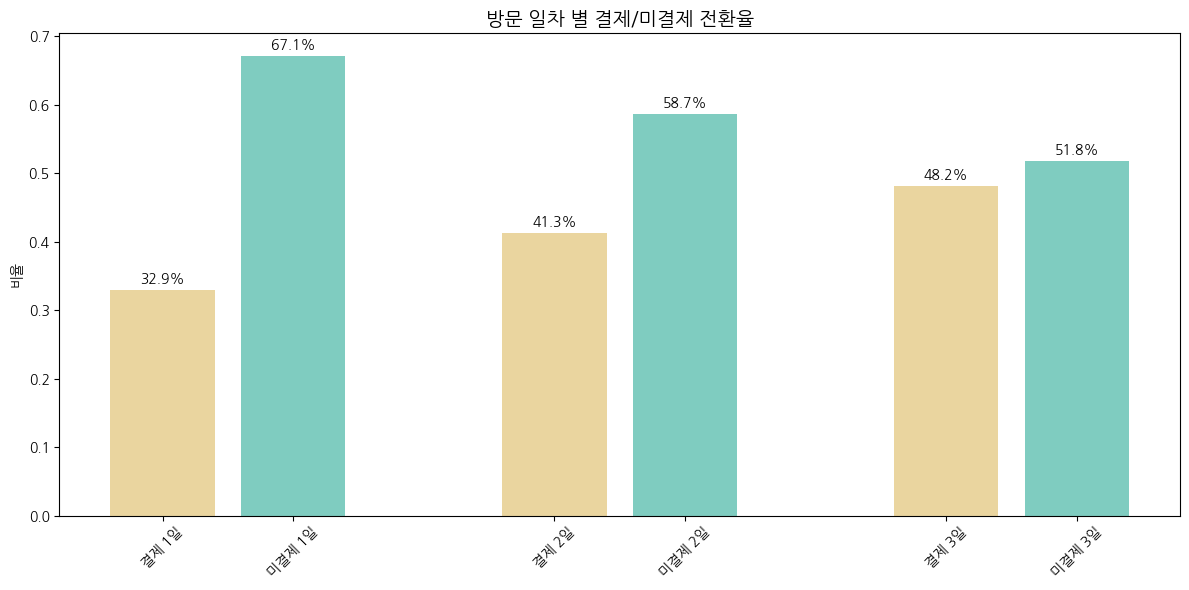

In [ ]:
df_conversion = df_merge[['user_uuid', 'visit_days', 'is_payment']]

In [ ]:
df_con_1 = df_conversion[df_conversion['visit_days']==1]
df_con_2 = df_conversion[df_conversion['visit_days']==2]
df_con_3 = df_conversion[df_conversion['visit_days']==3]

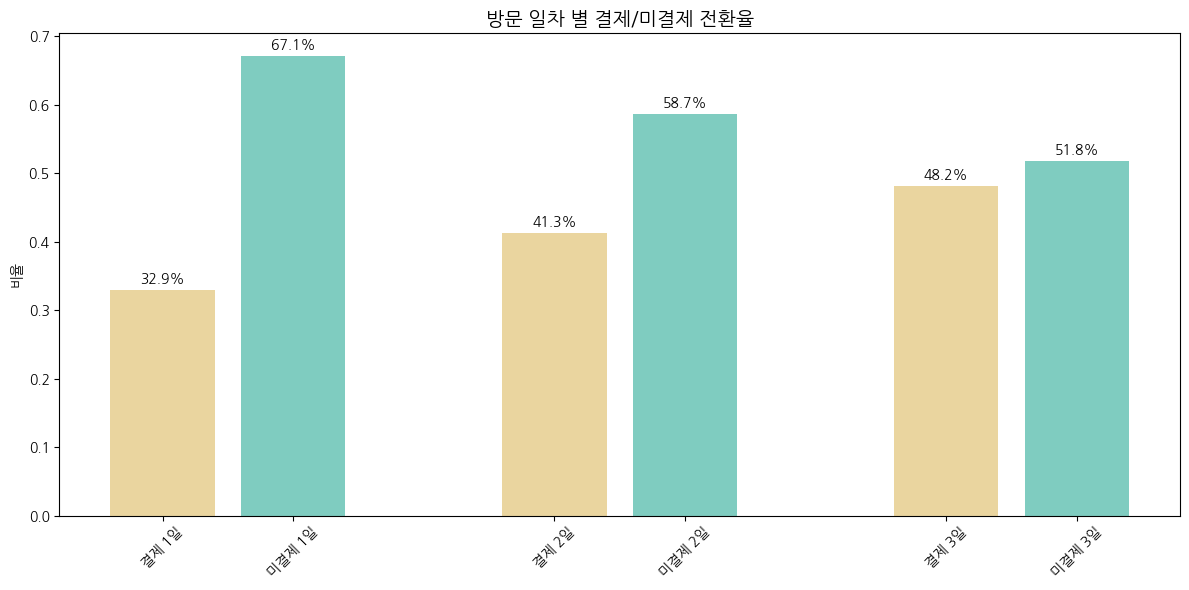

In [ ]:
# 1) visit_days별 전환율 계산
conv = (
    df_conversion.groupby('visit_days')['is_payment']
    .mean()
    .reset_index(name='conversion_rate')
)

# 2) 결제 → 미결제 값 생성
values = [
    conv.loc[conv['visit_days'] == 1, 'conversion_rate'].values[0],
    1 - conv.loc[conv['visit_days'] == 1, 'conversion_rate'].values[0],

    conv.loc[conv['visit_days'] == 2, 'conversion_rate'].values[0],
    1 - conv.loc[conv['visit_days'] == 2, 'conversion_rate'].values[0],

    conv.loc[conv['visit_days'] == 3, 'conversion_rate'].values[0],
    1 - conv.loc[conv['visit_days'] == 3, 'conversion_rate'].values[0],
]

labels = [
    "결제 1일", "미결제 1일",
    "결제 2일", "미결제 2일",
    "결제 3일", "미결제 3일"
]

# 3) x 위치 지정 (회차 사이 간격)
x = [0, 1,   3, 4,   6, 7]

# 4) BRBG 색 적용 (결제=블루/그린, 미결제=브라운)
cmap = plt.cm.BrBG
colors = [
    cmap(0.35),  # 결제 1일
    cmap(0.7),  # 미결제 1일
    cmap(0.35),  # 결제 2일
    cmap(0.7), # 미결제 2일
    cmap(0.35),  # 결제 3일
    cmap(0.7),  # 미결제 3일
]

# 5) 테두리 없는 그래프
plt.figure(figsize=(12,6))
plt.bar(x, values, color=colors)  # ← edgecolor 제거됨

plt.title("방문 일차 별 결제/미결제 전환율", fontsize=14)
plt.ylabel("비율")

# 값 표시
for xi, val in zip(x, values):
    plt.text(xi, val + 0.01, f"{val:.1%}", ha='center')

plt.xticks(x, labels, rotation=45)
plt.tight_layout()
plt.show()


## 4.2. 발견2 : 첫인상이 결제를 좌우한다.
---
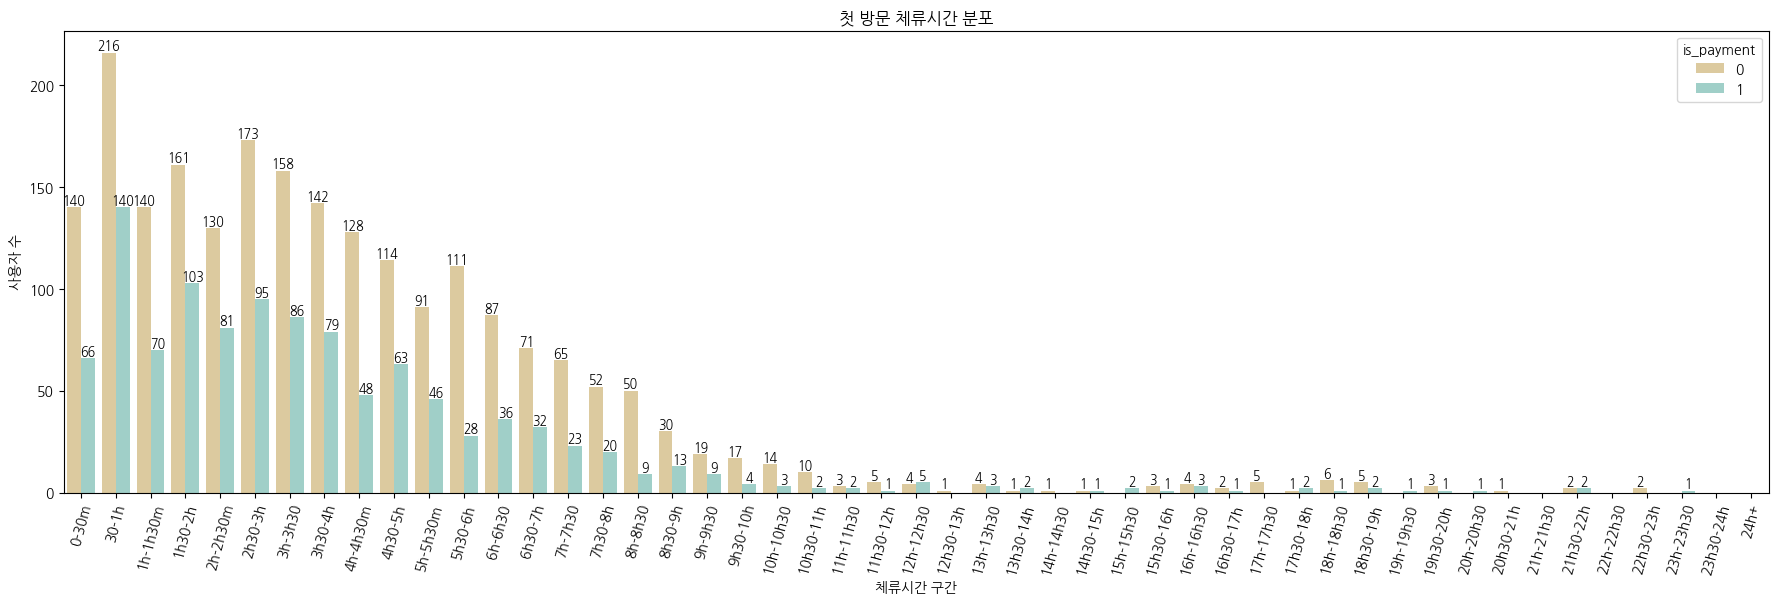
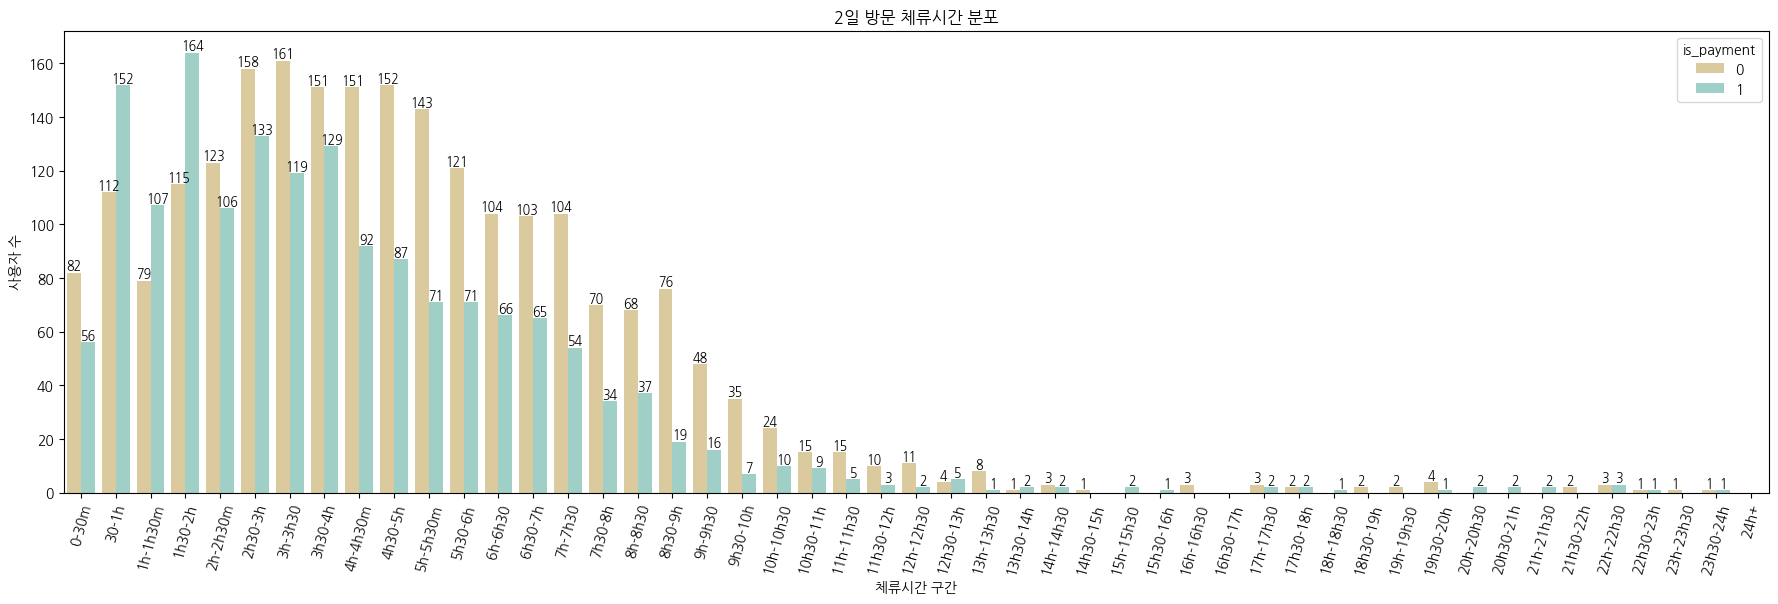
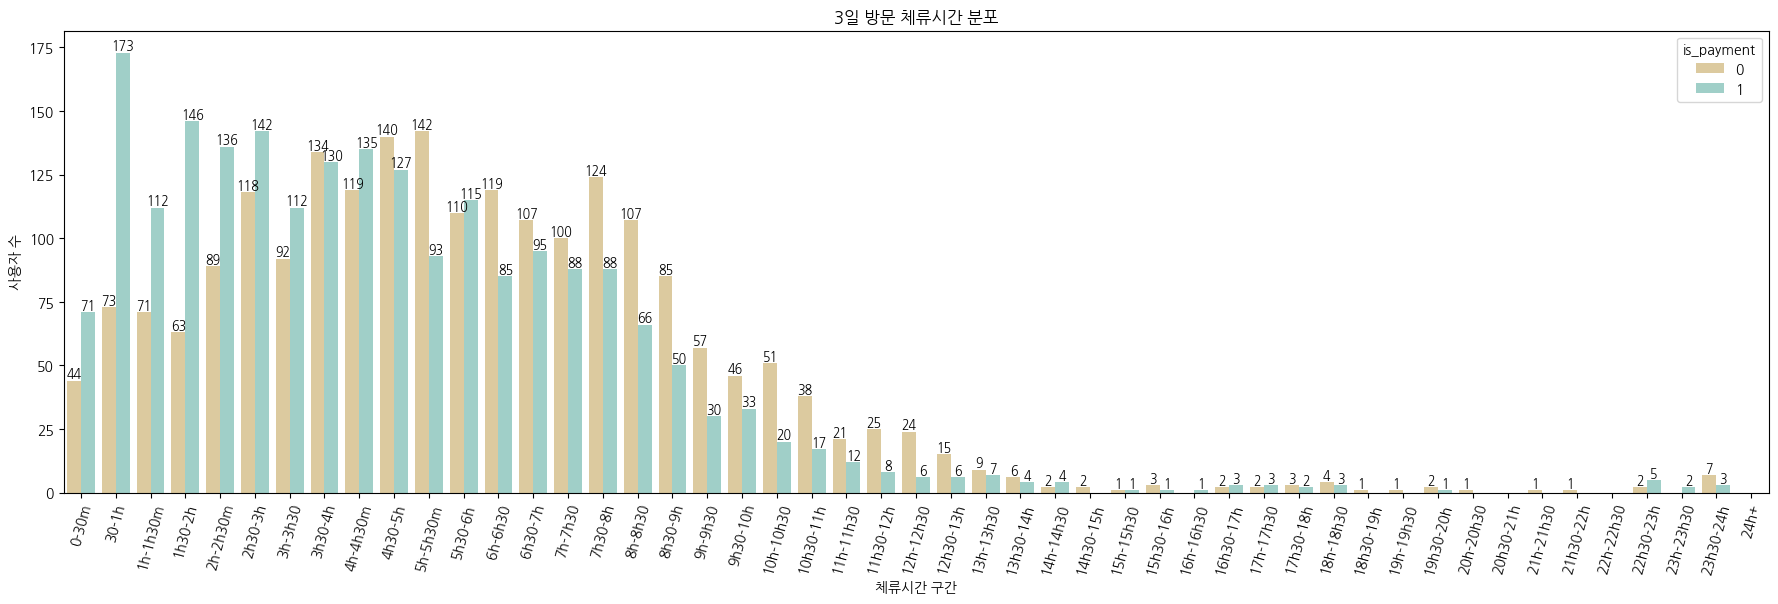

In [ ]:
# visit 날짜 변환
df_trial_visit_info['visit_dt'] = pd.to_datetime(df_trial_visit_info['date'], errors='coerce')

# user별 방문일수(고유 날짜 수)
visit_days = (
    df_trial_visit_info.groupby('user_uuid')['visit_dt']
         .nunique()
         .reset_index()
         .rename(columns={'visit_dt':'visit_days'})
)

# 4일 방문 → 3일 방문으로 통일
visit_days.loc[visit_days['visit_days'] >= 4, 'visit_days'] = 3

In [ ]:
# visit_days 시리즈 key : user_uuid
visit_days_series = visit_days.set_index('user_uuid')['visit_days']

users_all = visit_days_series.index.tolist()
users_first = visit_days_series[visit_days_series == 1].index.tolist()
users_revisit = visit_days_series[visit_days_series == 2].index.tolist()
users_3days = visit_days_series[visit_days_series >= 3].index.tolist()

groups = {
    "전체": users_all,
    "첫 방문": users_first,
    "2일 방문": users_revisit,
    "3일 방문": users_3days
}

In [ ]:
visit_merged = df_trial_visit_info.merge(df_site_area, on='site_id', how='left')
visit_merged = visit_merged.merge(df_user[['user_uuid','is_payment','visit_days']], on='user_uuid', how='left')

logs = {name: visit_merged[visit_merged['user_uuid'].isin(user_list)].copy() for name, user_list in groups.items()}

In [ ]:
for df_ in logs.values():
    df_['stay_min'] = df_['stay_time_second'] / 60.0

bins = [
    0,30,60,90,120,150,180,210,240,270,300,330,360,390,420,450,
    480,510,540,570,600,630,660,690,720,750,780,810,840,870,900,930,
    960,990,1020,1050,1080,1110,1140,1170,1220,1230,1260,1290,1320,1350,1380,1410,1440,2000
]
labels = [
    "0-30m","30-1h","1h-1h30m","1h30-2h","2h-2h30m","2h30-3h",
    "3h-3h30","3h30-4h","4h-4h30m","4h30-5h","5h-5h30m","5h30-6h",
    "6h-6h30","6h30-7h","7h-7h30","7h30-8h","8h-8h30","8h30-9h",
    "9h-9h30","9h30-10h","10h-10h30","10h30-11h","11h-11h30",
    "11h30-12h","12h-12h30","12h30-13h","13h-13h30","13h30-14h",
    "14h-14h30","14h30-15h","15h-15h30","15h30-16h","16h-16h30",
    "16h30-17h","17h-17h30","17h30-18h","18h-18h30","18h30-19h",
    "19h-19h30","19h30-20h","20h-20h30","20h30-21h","21h-21h30",
    "21h30-22h","22h-22h30","22h30-23h","23h-23h30","23h30-24h",
    "24h+"
]

for df_ in logs.values():
    df_['stay_bin'] = pd.cut(df_['stay_min'], bins=bins, labels=labels, include_lowest=True)

In [ ]:
def plot_stay_distribution(df, title):
    plt.figure(figsize=(22,6))
    sns.countplot(data=df, x='stay_bin', hue='is_payment', palette=palette)
    plt.title(title)
    plt.xlabel("체류시간 구간")
    plt.ylabel("사용자 수")
    plt.xticks(rotation=75)
    for c in plt.gca().containers:
        plt.bar_label(c, fontsize=9)
    plt.show()


==== 전체 ====



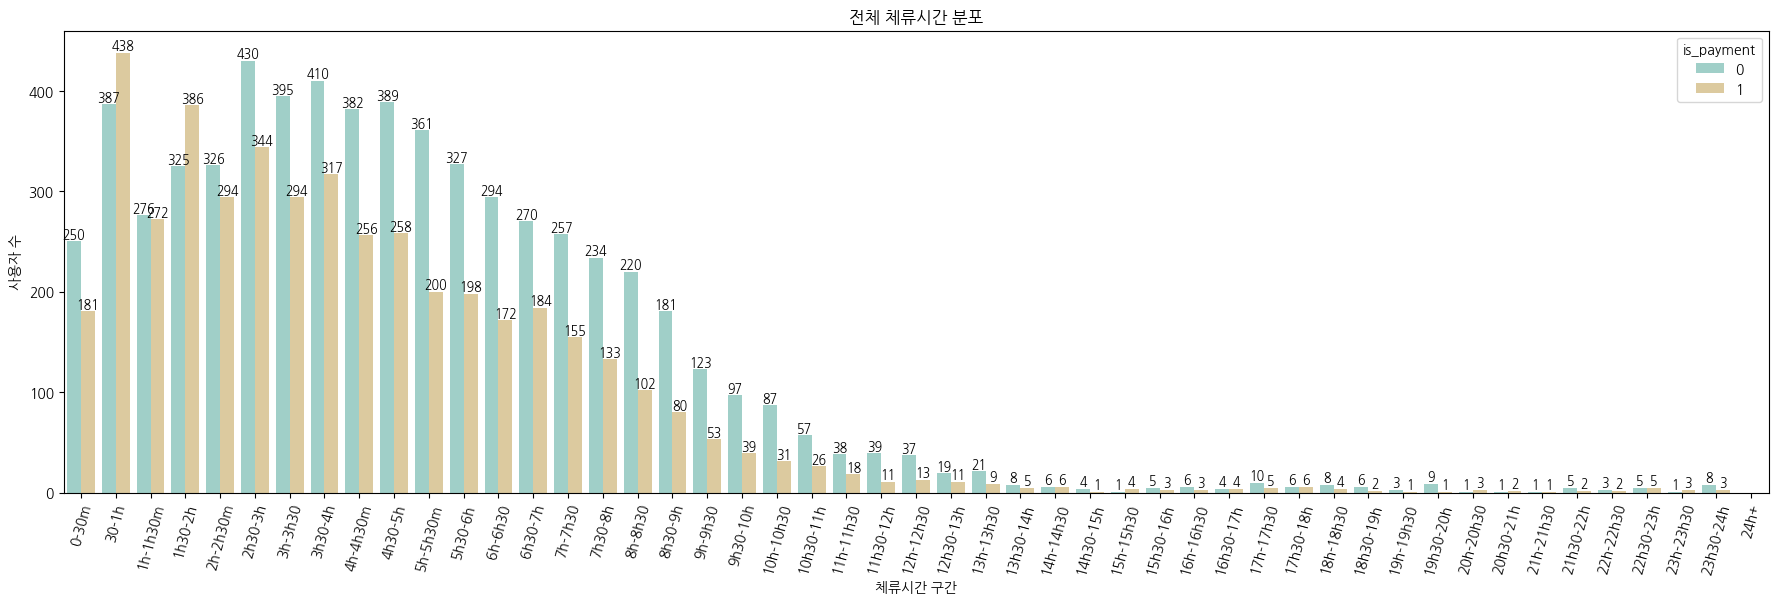


==== 첫 방문 ====



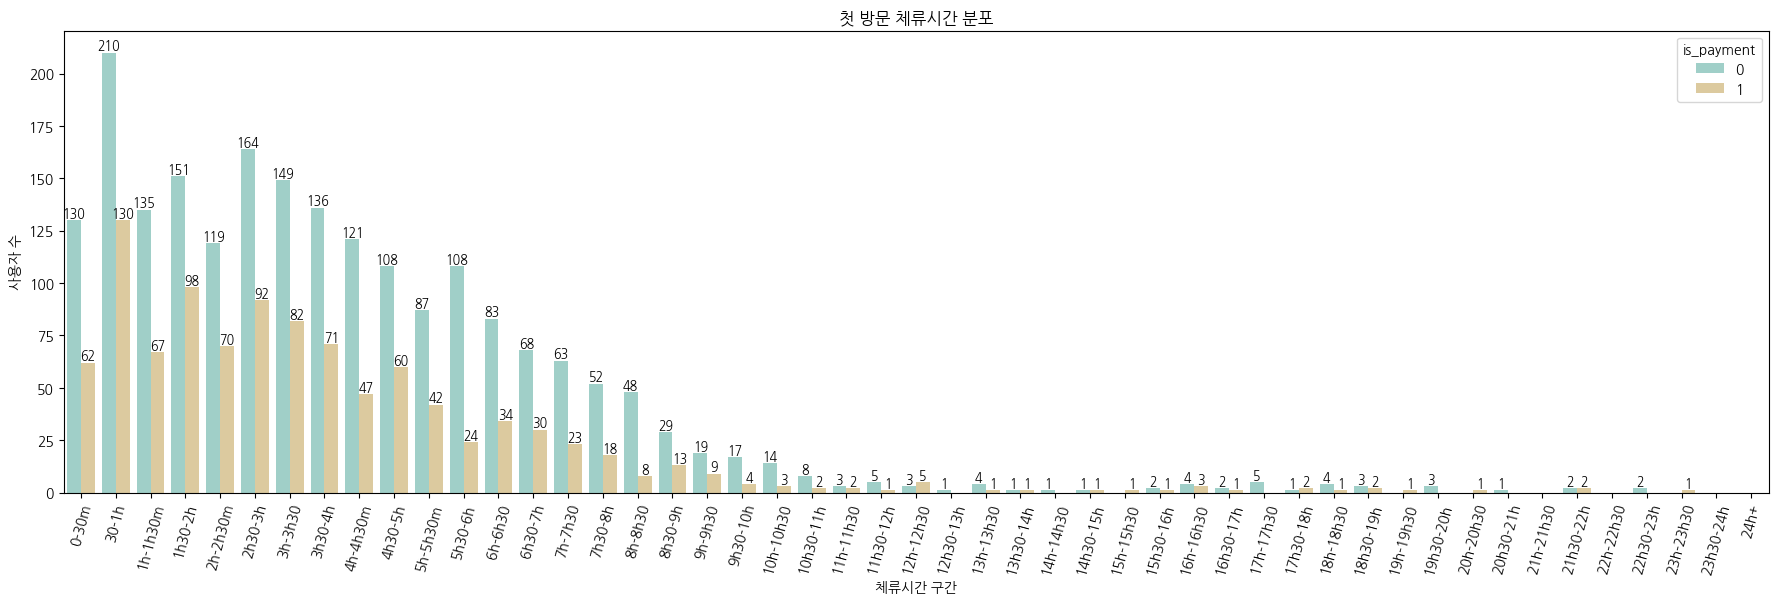


==== 2일 방문 ====



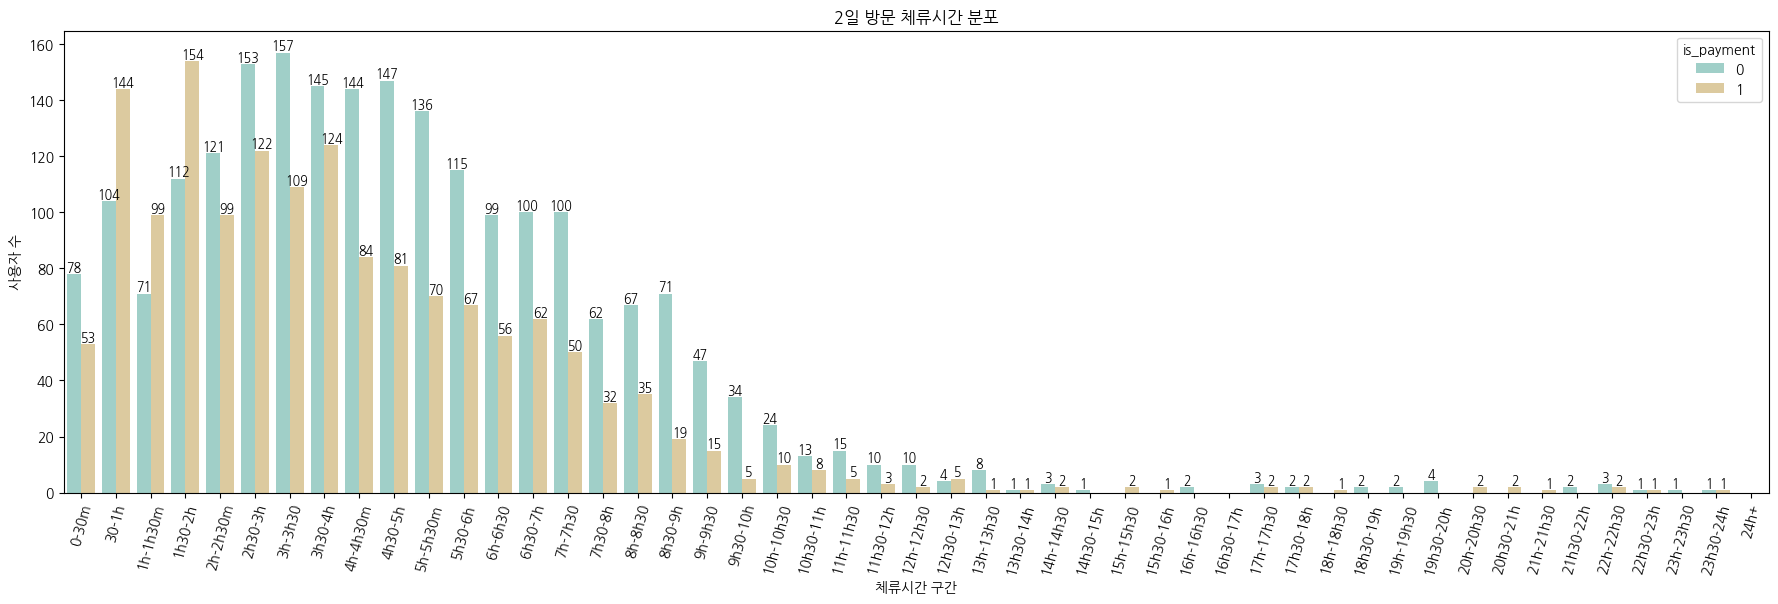


==== 3일 방문 ====



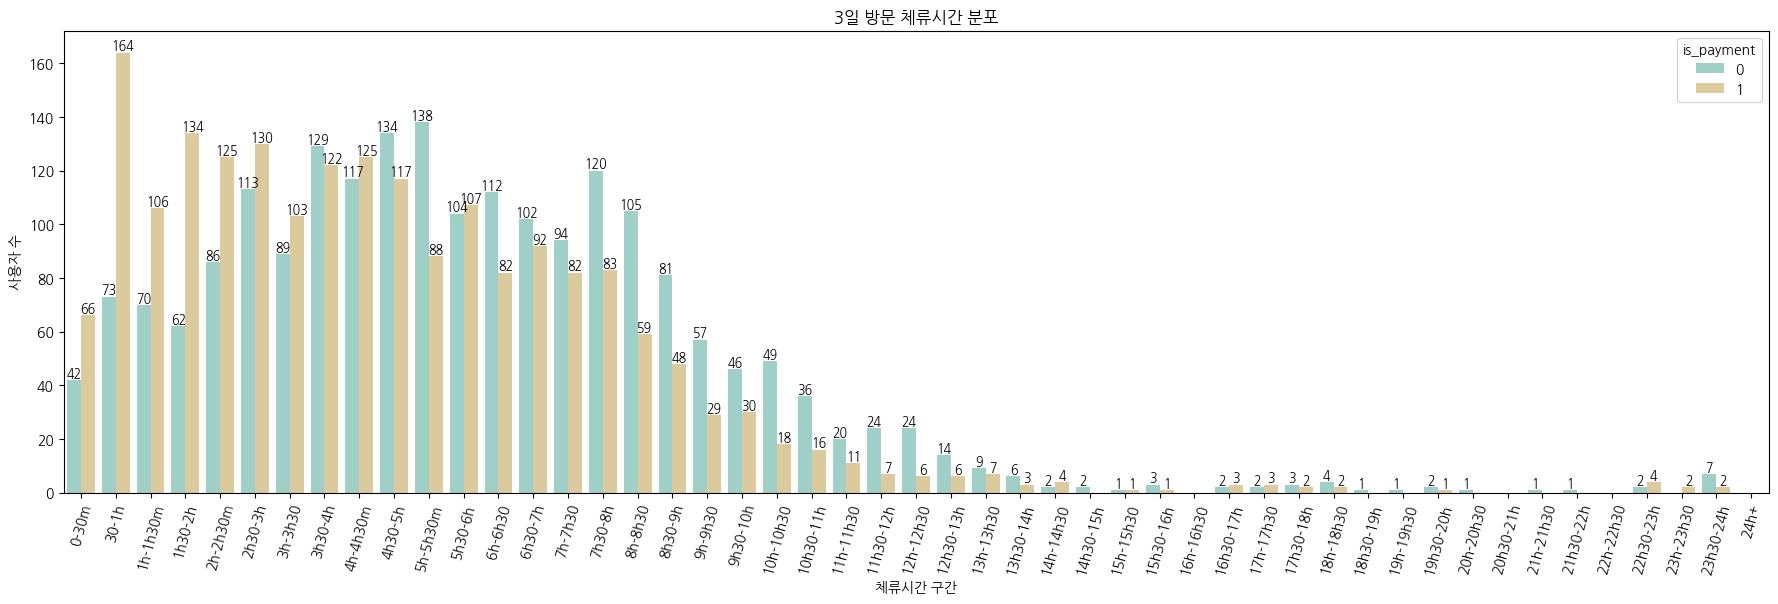

In [ ]:
for name, df_ in logs.items():
    print(f"\n==== {name} ====\n")
    plot_stay_distribution(df_, f"{name} 체류시간 분포")

## 4.3. 발견4 :  퇴근 후에 오는 사람들의 마음은 진심이다.
---
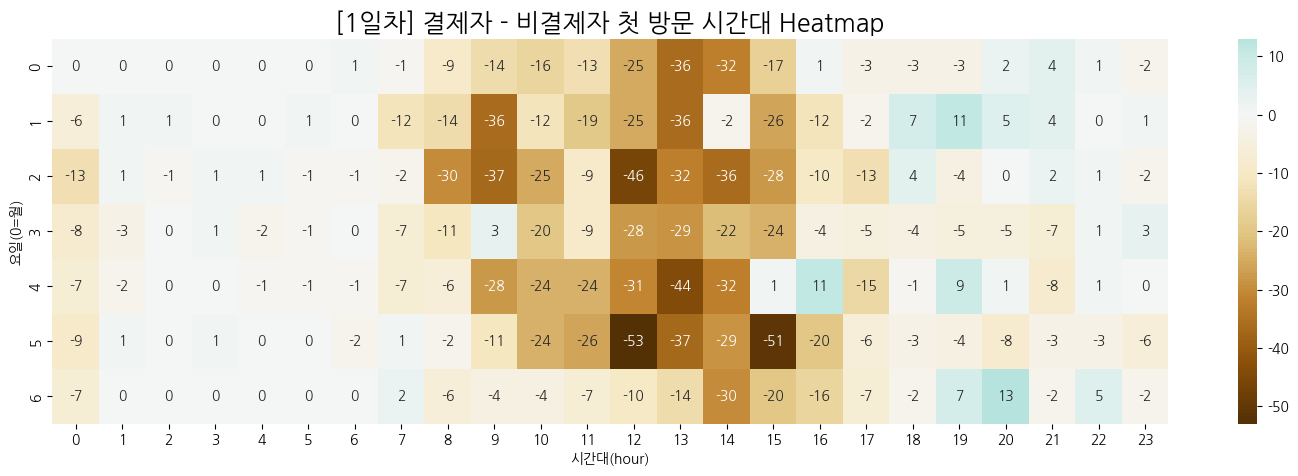
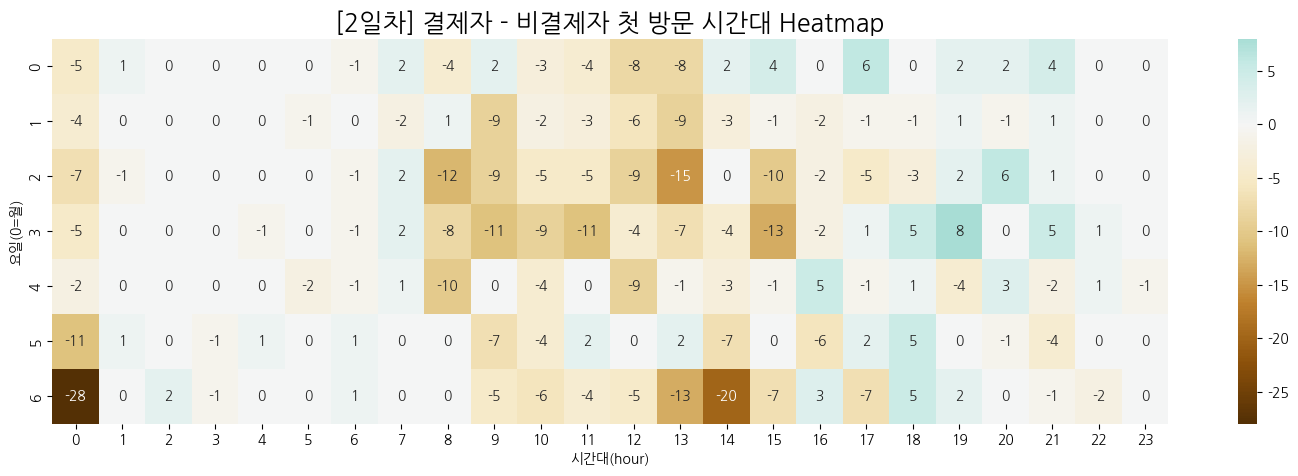
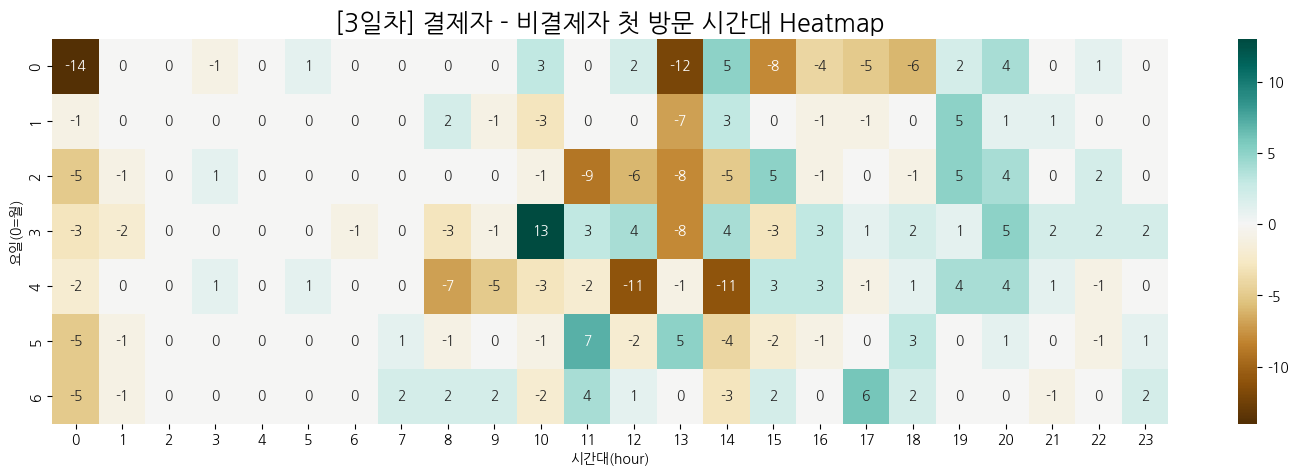

In [ ]:
df_first = df_merge[['initial_hour','day1_stay_time', 'day2_stay_time','day2_dow','day3_dow', 'day3_stay_time', 'day2_hour', 'day3_hour', 'is_payment']]

In [ ]:
# 1일차만 방문
day1_only = df_first[
    (df_first['day1_stay_time'] > 0) &
    (df_first['day2_stay_time'] == 0) &
    (df_first['day3_stay_time'] == 0)
]

# 2일까지 방문
day1_2 = df_first[
    (df_first['day1_stay_time'] > 0) &
    (df_first['day2_stay_time'] > 0) &
    (df_first['day3_stay_time'] == 0)
]

# 3일까지 방문
day1_2_3 = df_first[
    (df_first['day1_stay_time'] > 0) &
    (df_first['day2_stay_time'] > 0) &
    (df_first['day3_stay_time'] > 0)
]

In [ ]:
# heatmap 생성 함수
def create_heatmap(df, hour_col, dow_col, title):
    temp = df[[hour_col, dow_col, 'is_payment']].dropna()

    # 전체 grid 생성
    full_index = pd.MultiIndex.from_product(
        [range(7), range(24)],
        names=[dow_col, hour_col]
    )

    # 결제자/비결제자 개수 세기
    paid = temp[temp['is_payment'] == 1].groupby([dow_col, hour_col]).size()
    unpaid = temp[temp['is_payment'] == 0].groupby([dow_col, hour_col]).size()

    # 전체 grid로 재인덱싱 → 빠진 값은 0
    paid = paid.reindex(full_index, fill_value=0)
    unpaid = unpaid.reindex(full_index, fill_value=0)

    # 안전한 diff 계산
    diff = paid - unpaid

    # heatmap용 pivot
    heat = diff.unstack(level=1)

    # 시각화
    plt.figure(figsize=(18,5))
    sns.heatmap(heat, cmap='BrBG', center=0, annot=True, fmt='g')
    plt.title(title, fontsize=18)
    plt.xlabel("시간대(hour)")
    plt.ylabel("요일(0=월)")
    plt.show()




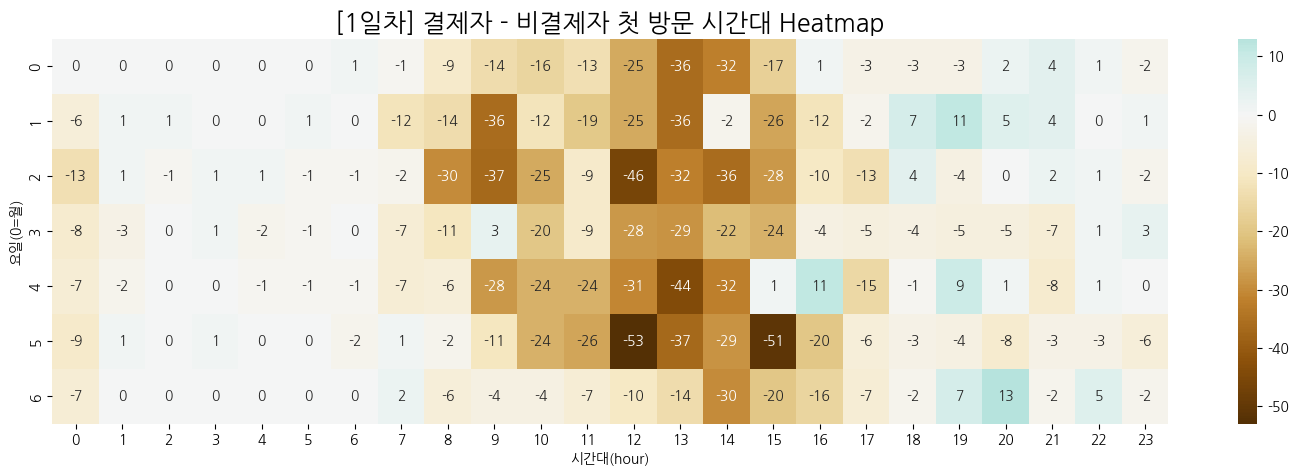

In [ ]:
create_heatmap(
    df_merge,
    hour_col='initial_hour',
    dow_col='initial_dow',
    title='[1일차] 결제자 - 비결제자 첫 방문 시간대 Heatmap'
)


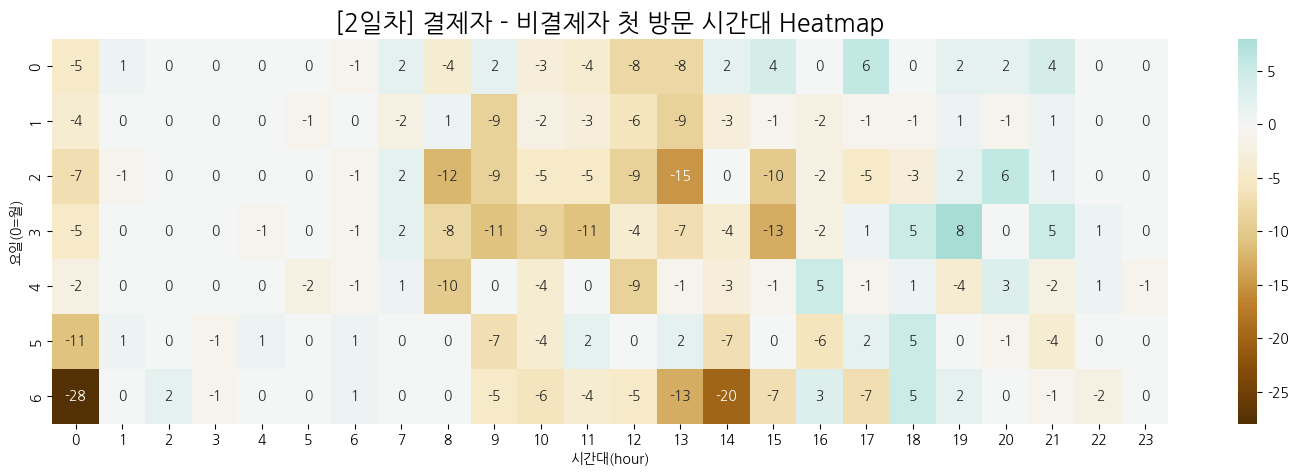

In [ ]:
create_heatmap(
    day1_2,
    hour_col='day2_hour',
    dow_col='day2_dow',
    title='[2일차] 결제자 - 비결제자 첫 방문 시간대 Heatmap'
)


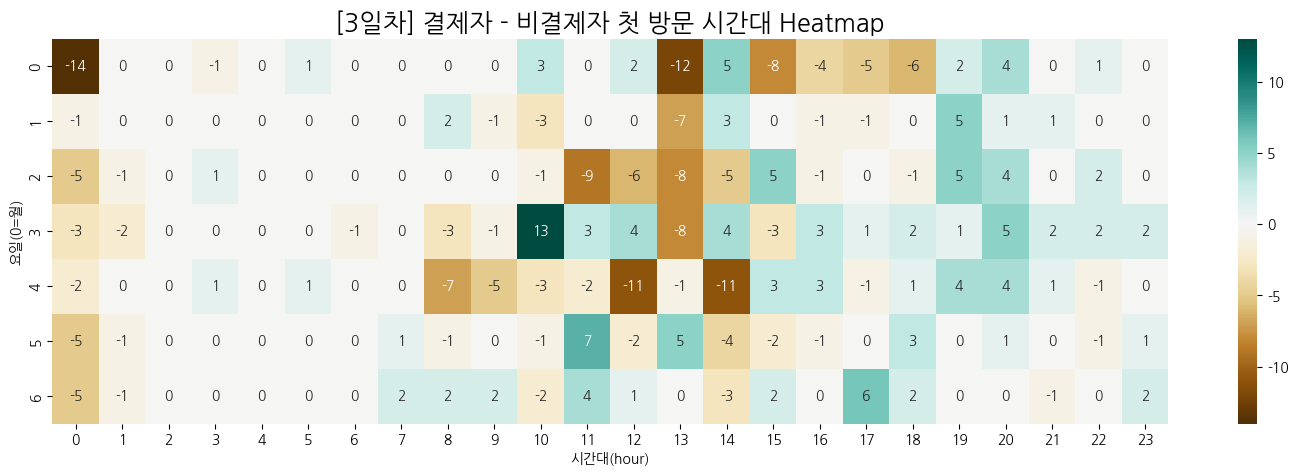

In [ ]:
create_heatmap(
    day1_2_3,
    hour_col='day3_hour',
    dow_col='day3_dow',
    title='[3일차] 결제자 - 비결제자 첫 방문 시간대 Heatmap'
)


## 4.4. 발견4 :  방문 지연 그룹은 유료 고객이 될 가능성이 높은 중요한 잠재 고객이다.
---
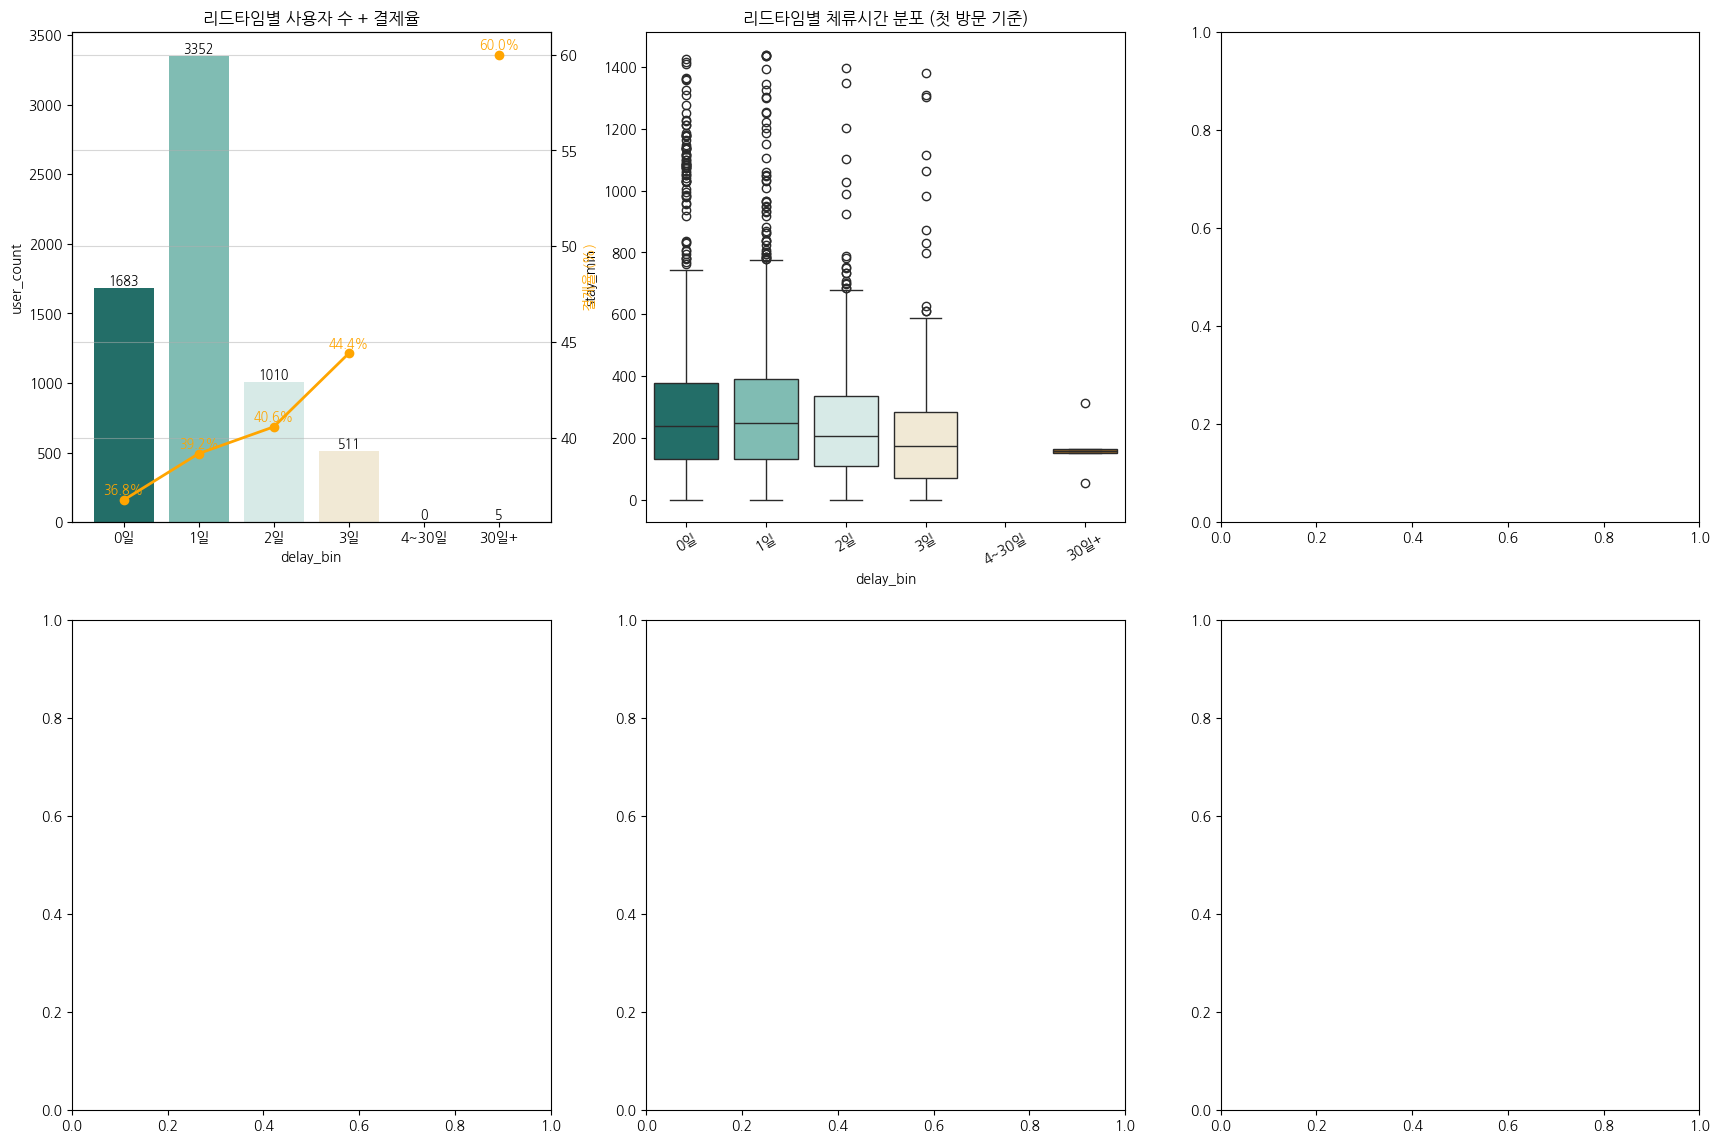

In [ ]:
# 등록일 변환
df_trial_register['reg_dt'] = pd.to_datetime(df_trial_register['trial_date'], errors='coerce')

# 최초 방문일
first_visit = (
    df_trial_visit_info.groupby('user_uuid')['visit_dt']
         .min()
         .reset_index()
         .rename(columns={'visit_dt':'first_visit_dt'})
)

In [ ]:
reg_visit = df_trial_register.merge(first_visit, on='user_uuid', how='left')

reg_visit['reserve_to_visit_days'] = (
    reg_visit['first_visit_dt'] - reg_visit['reg_dt']
).dt.days

# delay 구간화
reg_visit['delay_bin'] = pd.cut(
    reg_visit['reserve_to_visit_days'],
    bins=[-1, 0, 1, 2, 5, 10, 30, 999],
    labels=['0일', '1일', '2일', '3~5일', '6~10일', '11~30일', '30일+']
)

In [ ]:
# 이미 reg['reg_dt']와 first_visit 만듦
reg_visit = df_trial_register.merge(first_visit, on='user_uuid', how='left')
reg_visit['reserve_to_visit_days'] = (reg_visit['first_visit_dt'] - reg_visit['reg_dt']).dt.days
reg_visit['reserve_to_visit_days'] = reg_visit['reserve_to_visit_days'].fillna(-1).astype(int)

reg_visit['delay_bin'] = pd.cut(
    reg_visit['reserve_to_visit_days'],
    bins=[-1, 0, 1, 2, 4, 30, 999],
    labels=['0일','1일','2일','3일','4~30일','30일+']
)

In [ ]:
# 결제율 by delay_bin
delay_pay = reg_visit.merge(df_user[['user_uuid','is_payment']], on='user_uuid', how='left').fillna({'is_payment':0})
payment_rate = delay_pay.groupby('delay_bin')['is_payment'].mean().reset_index(name='payment_rate')

/tmp/ipython-input-3118732610.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  payment_rate = delay_pay.groupby('delay_bin')['is_payment'].mean().reset_index(name='payment_rate')


In [ ]:
# 첫 방문 레코드만 추출 -> stay_delay (첫 방문 기준 체류시간)
first_records = visit_merged.sort_values(['user_uuid','first_enter_time']).groupby('user_uuid').head(1)
first_records['stay_min'] = first_records['stay_time_second'] / 60.0

stay_delay = first_records.merge(reg_visit[['user_uuid','delay_bin']], on='user_uuid', how='left')
stay_summary = stay_delay.groupby('delay_bin')['stay_min'].mean().reset_index()

/tmp/ipython-input-333260452.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stay_summary = stay_delay.groupby('delay_bin')['stay_min'].mean().reset_index()


/tmp/ipython-input-2732010319.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delay_count = delay_pay.groupby('delay_bin')['user_uuid'].count().reset_index(name='user_count')
/tmp/ipython-input-2732010319.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_delay,
/tmp/ipython-input-2732010319.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=stay_delay,


<Figure size 2000x1600 with 0 Axes>

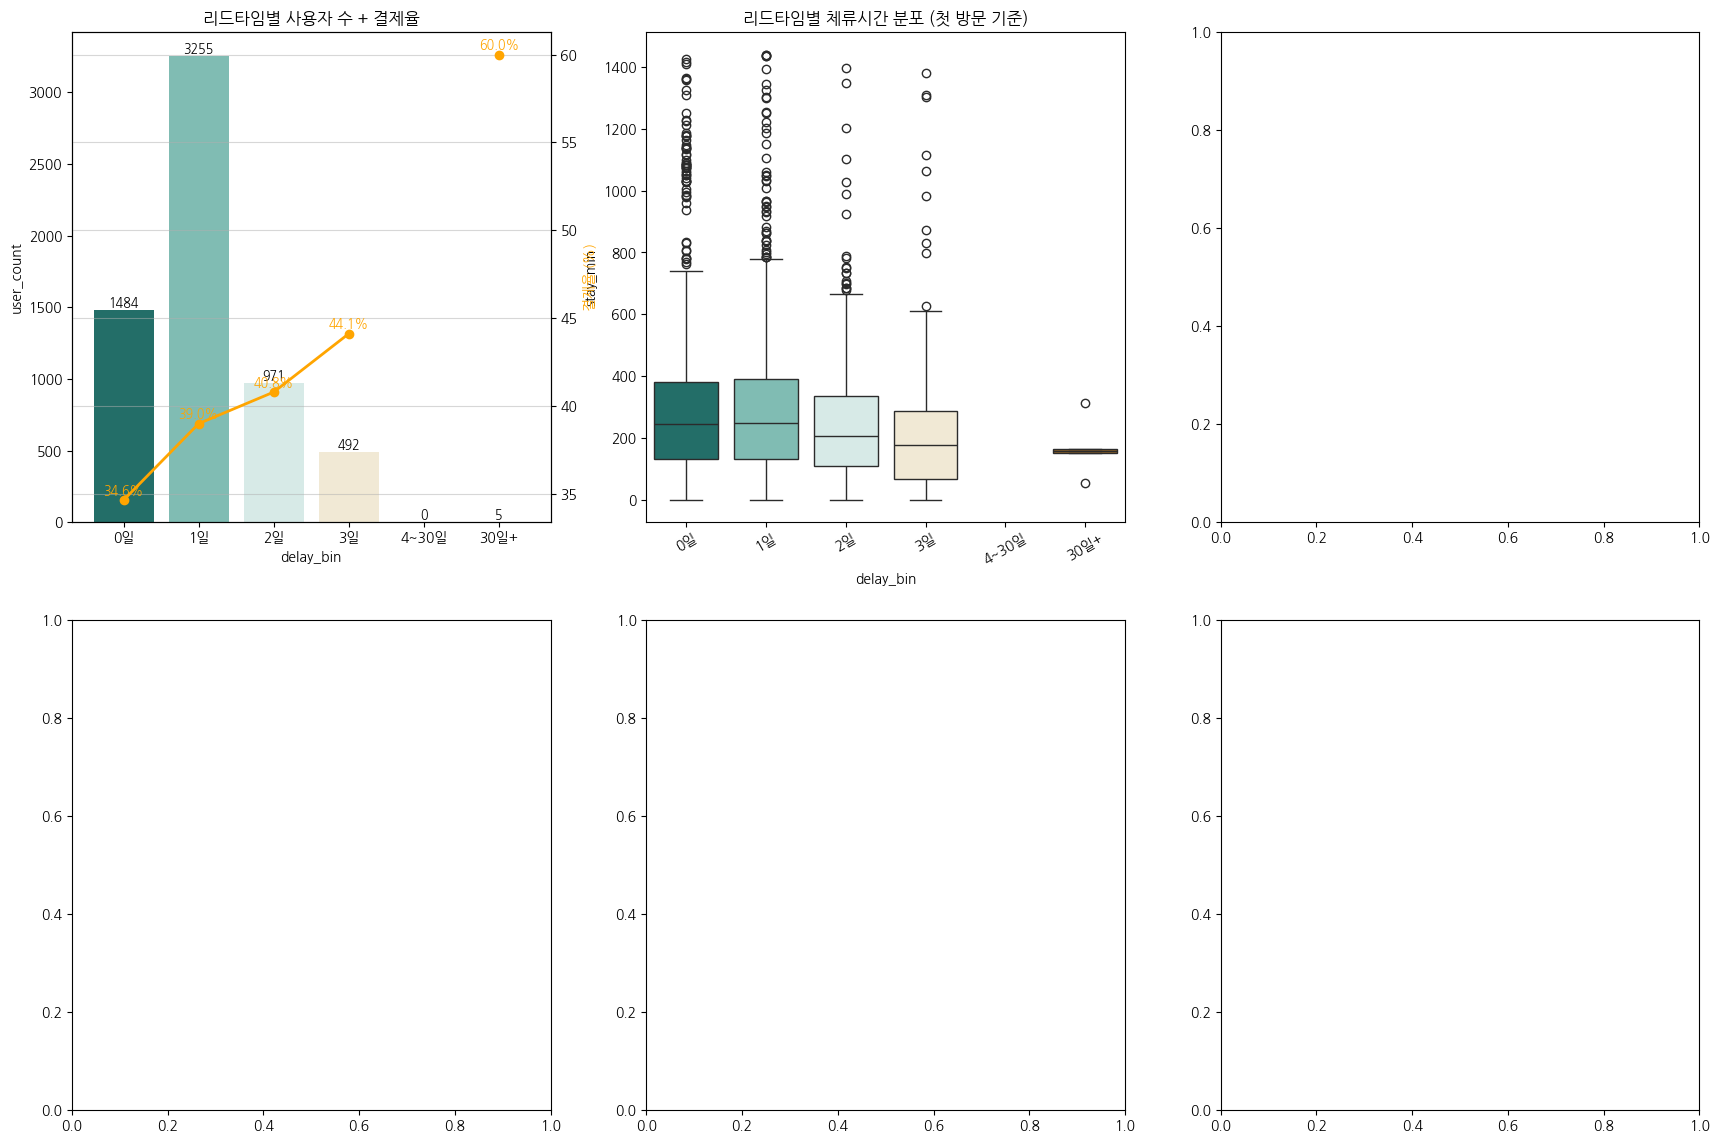

In [ ]:
# delay_bin 기준 종합 시각화 (6개: 사용자수+결제율, 체류시간 box, 요일, 시간대, 지점, 평균체류)

plt.figure(figsize=(20,16))
fig, axes = plt.subplots(2,3, figsize=(21,14))
axes = axes.flatten()
palette = "BrBG_r"

# -----------------------------------------
# 1) delay_bin별 사용자 수 + 결제율
# -----------------------------------------
delay_count = delay_pay.groupby('delay_bin')['user_uuid'].count().reset_index(name='user_count')
summary_delay = delay_count.merge(payment_rate, on='delay_bin', how='left')
delay_order = ['0일','1일','2일','3일','4~30일','30일+']

sns.barplot(data=summary_delay,
            x='delay_bin',
            y='user_count',
            palette=palette,
            ax=axes[0]
            )
axes[0].set_title("리드타임별 사용자 수 + 결제율")

for c in axes[0].containers:
    axes[0].bar_label(c, fontsize=9)

ax2d = axes[0].twinx()

summary_delay = summary_delay.sort_values(
    'delay_bin'
).reset_index(drop=True)

# --- line plot 전 반드시 Categorical 기준으로 정렬 ---
summary_delay = summary_delay.sort_values('delay_bin').reset_index(drop=True)

ax2d.plot(
    summary_delay['delay_bin'],
    summary_delay['payment_rate']*100,
    marker='o',
    color='orange',
    linewidth=2
)

ax2d.set_ylabel("결제율 (%)", color='orange')
ax2d.grid(alpha=0.5)

for x,y in zip(summary_delay['delay_bin'], summary_delay['payment_rate']*100):
    ax2d.text(x, y+0.3, f"{y:.1f}%", ha='center', fontsize=9, color='orange')


# -----------------------------------------
# 2) 체류시간 boxplot (first visit)
# -----------------------------------------
sns.boxplot(data=stay_delay,
            x='delay_bin',
            y='stay_min',
            palette=palette,
            ax=axes[1],
            order=delay_order
            )
axes[1].set_title("리드타임별 체류시간 분포 (첫 방문 기준)")
axes[1].tick_params(axis='x', labelrotation=30)

## 4.5. 발견5 : 3일 완주 그룹은 ‘처음부터 목적성이 높은 사용자’이다.
___
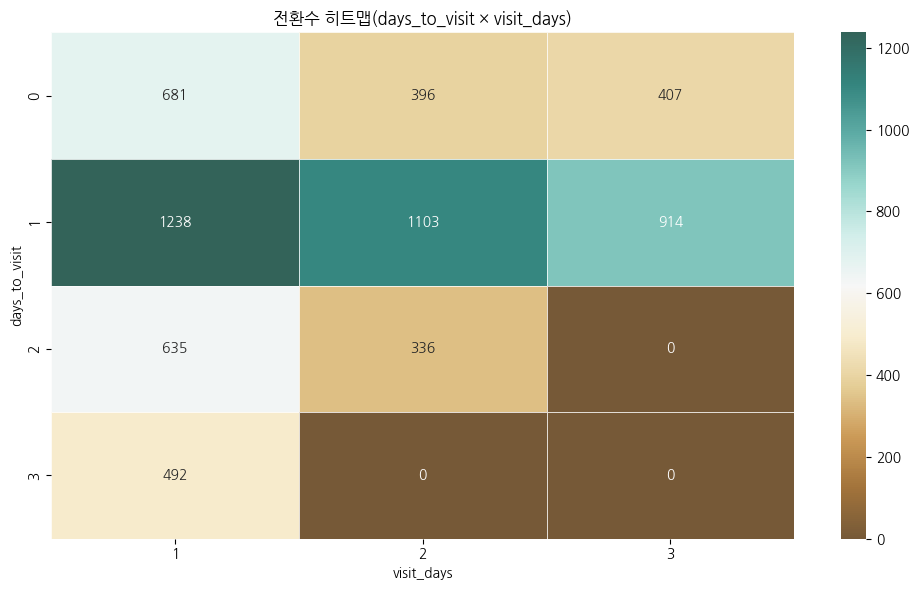
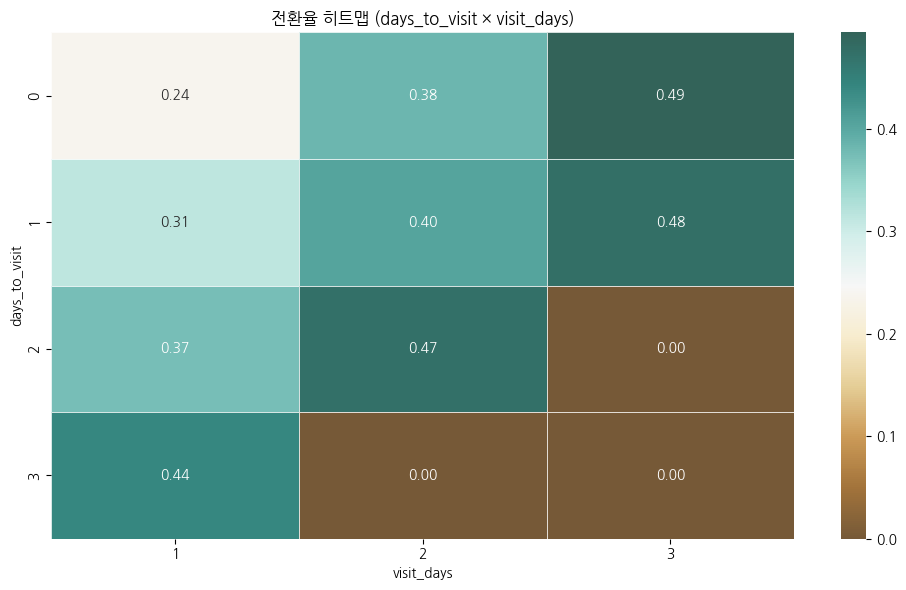

In [ ]:
df_hours = df_merge[['user_uuid','visit_days', 'days_to_visit', 'initial_dow', 'initial_hour','day2_dow', 'day2_hour','day3_dow','day3_hour','is_payment']]

In [ ]:
df_hours = df_hours[df_hours['days_to_visit']<=3]

In [ ]:
pivot_days = df_hours.pivot_table(
    index='days_to_visit',
    columns='visit_days',
    values='user_uuid',   # 아무 컬럼이나 넣고 count/sum 의미 없음
    aggfunc='count',
    fill_value=0
)

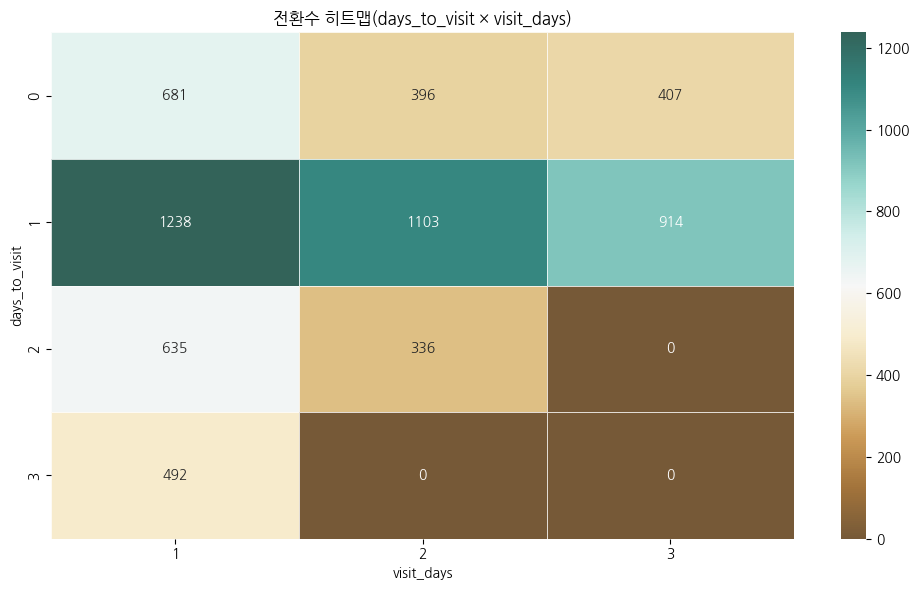

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot_days,
    annot=True,
    fmt="d",
    cmap='BrBG', alpha=0.8,
    linewidths=.5
)

plt.title("전환수 히트맵(days_to_visit × visit_days)")
plt.xlabel("visit_days")
plt.ylabel("days_to_visit")

plt.tight_layout()
plt.show()


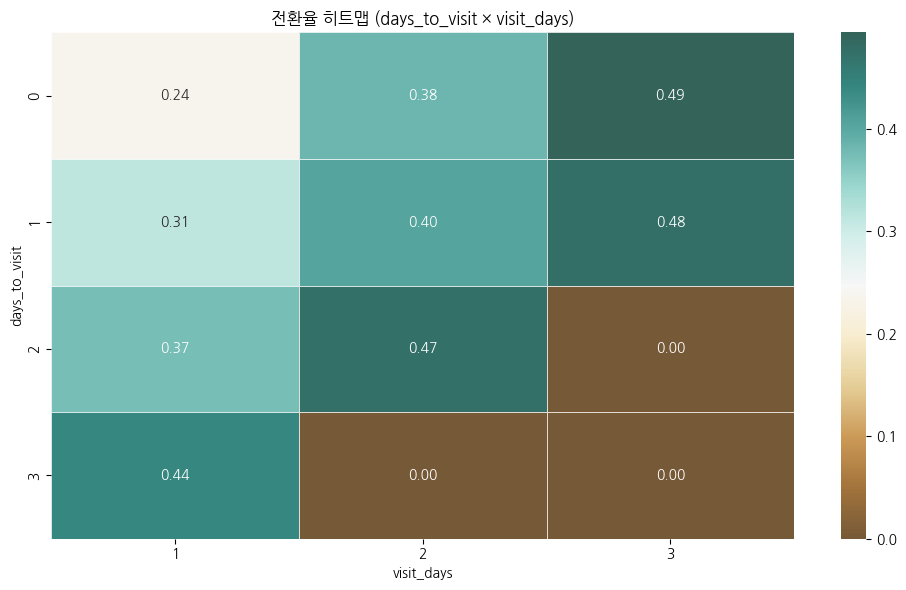

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------
# 1) 전환율 피벗 테이블 생성
# ----------------------------
pivot_rate = df_hours.pivot_table(
    index='days_to_visit',
    columns='visit_days',
    values='is_payment',   # 0/1 → 평균 = 전환율
    aggfunc='mean',
    fill_value=0
)

# ----------------------------
# 2) index와 columns 정렬 (숫자 순서 보장)
# ----------------------------
pivot_rate = pivot_rate.reindex(sorted(pivot_rate.index))
pivot_rate = pivot_rate.reindex(sorted(pivot_rate.columns), axis=1)

# ----------------------------
# 3) 히트맵 시각화
# ----------------------------
plt.figure(figsize=(10,6))

sns.heatmap(
    pivot_rate,
    annot=True,
    fmt=".2f",          # 전환율이므로 소수 2자리
    cmap="BrBG",alpha=0.8,
    linewidths=.5
)

plt.title("전환율 히트맵 (days_to_visit × visit_days)")
plt.xlabel("visit_days")
plt.ylabel("days_to_visit")

plt.tight_layout()
plt.show()


# 사용한 모델 및 군집분석

## 5 모델링 – RandomForest + SMOTE.

In [ ]:
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

In [ ]:
# 5. Modeling : 중요도 80% 피처 선택 + RandomForest + SMOTE
# ==========================================================
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, classification_report
)

import numpy as np
import pandas as pd

print("\n[5. Modeling 시작]")

# 공통 데이터 준비
df = df_merge.copy()
df_clean = df[df["visit_days"].notna()].copy()   # 방문 0일 제외

TARGET = "is_payment"

# ------------------------------------------
# 5-1. 숫자형 컬럼만 feature 후보로 사용 (timestamp 자동 제외)
# ------------------------------------------
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()
feature_cols_all = [c for c in numeric_cols if c != TARGET]

print("전체 숫자형 피처 수:", len(feature_cols_all))
print("전체 숫자형 피처 목록:", feature_cols_all)

X_all = df_clean[feature_cols_all].fillna(df_clean[feature_cols_all].median())
y_all = df_clean[TARGET].astype(int)

# ------------------------------------------
# 5-2. 베이스라인 RandomForest (SMOTE 없이) → 중요도 계산용
# ------------------------------------------
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all,
    test_size=0.3,
    stratify=y_all,
    random_state=42
)

rf_base = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_base.fit(X_tr, y_tr)

y_proba_base = rf_base.predict_proba(X_te)[:, 1]
y_pred_base  = rf_base.predict(X_te)

print("\n[베이스라인 RF 성능] (전체 숫자형 피처 사용)")
print("AUC      :", roc_auc_score(y_te, y_proba_base))
print("Accuracy :", accuracy_score(y_te, y_pred_base))
print(classification_report(y_te, y_pred_base))

importances = (
    pd.Series(rf_base.feature_importances_, index=feature_cols_all)
    .sort_values(ascending=False)
)

print("\n[피처 중요도 Top 20]")
print(importances.head(20))

# ------------------------------------------
# 5-3. 중요도 기반 피처 선택 (누적 중요도 80% 기준)
# ------------------------------------------
threshold = 0.80  # 누적 중요도 80%까지 사용

cum_imp = importances.cumsum()
selected_features = cum_imp[cum_imp <= threshold].index.tolist()

print("\n[선택된 피처 목록] (누적 중요도 80%)")
print(selected_features)
print("선택된 피처 개수:", len(selected_features))

# ------------------------------------------
# 5-4. 선택된 피처만으로 RF + SMOTE 최종 모델
# ------------------------------------------
X_sel = df_clean[selected_features].fillna(df_clean[selected_features].median())
y_sel = df_clean[TARGET].astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_sel, y_sel,
    test_size=0.3,
    stratify=y_sel,
    random_state=42
)

print("\n[RF + SMOTE] 적용 전 클래스 비율:", np.bincount(y_tr))

smote = SMOTE(random_state=42, k_neighbors=5)
X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)

print("[RF + SMOTE] 적용 후 클래스 비율:", np.bincount(y_tr_sm))

rf_smote = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_tr_sm, y_tr_sm)

y_proba_sm = rf_smote.predict_proba(X_te)[:, 1]
y_pred_sm  = (y_proba_sm > 0.5).astype(int)

print("\n🔥 [선택 피처 + RF + SMOTE] 최종 결과")
print("AUC      :", roc_auc_score(y_te, y_proba_sm))
print("Accuracy :", accuracy_score(y_te, y_pred_sm))
print(classification_report(y_te, y_pred_sm))

fi_df = (
    pd.DataFrame({
        "feature": selected_features,
        "importance": rf_smote.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

print("\n[최종 모델 중요도 Top 20]")
print(fi_df.head(20))


[5. Modeling 시작]
전체 숫자형 피처 수: 26
전체 숫자형 피처 목록: ['day1_stay_time', 'day2_stay_time', 'day3_stay_time', 'drop_12', 'drop_23', 'visit_days', 'initial_sin_week', 'initial_cos_week', 'initial_sin_hour', 'initial_cos_hour', 'initial_sin_month', 'initial_cos_month', 'day2_dow', 'day2_hour', 'day2_sin_hour', 'day2_cos_hour', 'day3_dow', 'day3_hour', 'day3_sin_hour', 'day3_cos_hour', 'day1_site_id', 'day2_site_id', 'day3_site_id', 'days_to_visit', 'trial_sin_week', 'trial_cos_week']

[베이스라인 RF 성능] (전체 숫자형 피처 사용)
AUC      : 0.6464676290463692
Accuracy : 0.6349973161567365
              precision    recall  f1-score   support

           0       0.68      0.78      0.72      1143
           1       0.54      0.41      0.47       720

    accuracy                           0.63      1863
   macro avg       0.61      0.59      0.59      1863
weighted avg       0.62      0.63      0.62      1863


[피처 중요도 Top 20]
day1_stay_time       0.132991
drop_12              0.116975
day2_stay_time       0.062

## 6.군집분석


[6. Clustering (원래 방식) 시작]
k=2 → silhouette=0.3756
k=3 → silhouette=0.3789
k=4 → silhouette=0.3004
k=5 → silhouette=0.3062
k=6 → silhouette=0.3097
k=7 → silhouette=0.3123


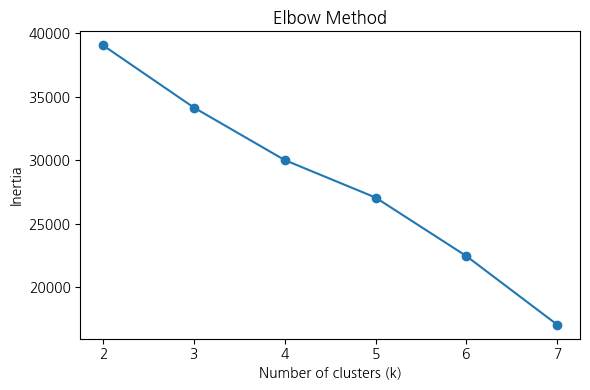


[군집 프로파일링 결과 (원래 방식, k=4)]
         users  visit_days  day1_stay_time  day2_stay_time  day3_stay_time  \
cluster                                                                      
0         2374    1.406066    14323.144903     4913.157961      120.460404   
1         1329    2.871332    23078.778029    23703.266366    17534.045899   
2            4    1.750000    10377.000000     6745.000000     1893.250000   
3         2500    1.410400    14395.543200     4935.510000      177.821200   

          drop_12   drop_23  days_to_visit  site_id_encoded  payment_rate  \
cluster                                                                     
0        0.382043  0.309912       1.188290         0.351683      0.344566   
1       -3.695172 -1.412506       0.731377         0.385178      0.429646   
2       -0.694362  0.409174     217.000000         0.369494      0.500000   
3        0.326966  0.291712       1.185200         0.420291      0.403200   

         initial_hour  
cluster         

In [ ]:
# 6. Clustering :
#   - visit_days >= 1만 사용
#   - site_id_encoded 포함
#   - StandardScaler + KMeans(k=4)
# ==========================================================

print("\n[6. Clustering (원래 방식) 시작]")

# 6-1. 분석 대상: visit_days 가 NaN 이 아닌 고객만 사용
df_clean = df[df["visit_days"].notna()].copy()

# 군집용 데이터프레임 복사
df_cluster = df_clean.copy()

# 6-2. Day1 방문 지점별 평균 결제율로 site_id 인코딩 (원래 방식)
site_te = df_cluster.groupby("day1_site_id")["is_payment"].mean()
df_cluster["site_id_encoded"] = df_cluster["day1_site_id"].map(site_te)

# 6-3. 군집에 사용할 변수 세트 (원래 쓰던 8개)
cluster_features = [
    "day1_stay_time",
    "day2_stay_time",
    "day3_stay_time",
    "days_to_visit",
    "visit_days",
    "drop_12",
    "drop_23",
    "site_id_encoded"
]

X_cluster = df_cluster[cluster_features].fillna(0)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 6-4. StandardScaler 로 스케일링 (원래 코드 그대로)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 6-5. Elbow + Silhouette 확인 (옵션, 보고서용)
inertia = []
sil_scores = {}
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    sil_scores[k] = sil
    print(f"k={k} → silhouette={sil:.4f}")

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

# 6-6. 최종 k=4로 KMeans 학습 (원래 설정)
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
df_cluster["cluster"] = kmeans.fit_predict(X_scaled)

# 6-7. 군집 프로파일링 (원래 포맷 기반, 있는 컬럼만 사용)
agg_dict = {
    "user_uuid": "count",
    "visit_days": "mean",
    "day1_stay_time": "mean",
    "day2_stay_time": "mean",
    "day3_stay_time": "mean",
    "drop_12": "mean",
    "drop_23": "mean",
    "days_to_visit": "mean",
    "site_id_encoded": "mean",
    "is_payment": "mean",
}

# initial_hour 컬럼이 있으면 같이 집계
if "initial_hour" in df_cluster.columns:
    agg_dict["initial_hour"] = "mean"

profile = df_cluster.groupby("cluster").agg(agg_dict)
profile.rename(
    columns={
        "user_uuid": "users",
        "is_payment": "payment_rate"
    },
    inplace=True
)

print("\n[군집 프로파일링 결과 ( k=4)]")
print(profile)
print("\n클러스터별 인원수:")
print(df_cluster["cluster"].value_counts())

In [ ]:
from sklearn.metrics import silhouette_score

sil_scores = {}

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores[k] = sil

sil_scores

{2: np.float64(0.37563865922222633),
 3: np.float64(0.3788766943124633),
 4: np.float64(0.3003869565290509),
 5: np.float64(0.306207567512345),
 6: np.float64(0.3097489186505413),
 7: np.float64(0.3123321332169338)}

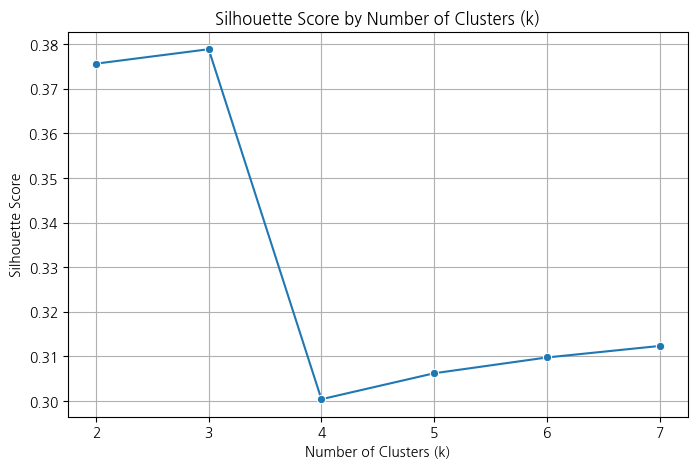

In [ ]:
plt.figure(figsize=(8,5))
sns.lineplot(x=list(sil_scores.keys()), y=list(sil_scores.values()), marker="o")
plt.title("Silhouette Score by Number of Clusters (k)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [ ]:
df_cluster.groupby("cluster")["visit_days"].mean().round(2)

,visit_days
cluster,
0,1.41
1,2.87
2,1.75
3,1.41
